# 耕作地割合：カロリーポテンシャル限定・土壌群追加・Spatial OOF LightGBM

現地と周辺の農業ポテンシャルをカロリー指標に統一した二段階LightGBMです。
永久湿地（exclusion class 5）は推定対象から除外し、5-fold Spatial OOFで評価します。

## 分析仕様

- 現地：天水カロリーポテンシャル、灌漑によるカロリー増分
- 周辺：50 kmの天水カロリーポテンシャルのみ
- 水資源：現地GloFAS流量、一定規模以上の河川までの距離
- 土地：標高、傾斜、環境除外区分、WRB土壌群
- 市場アクセス：都市・港までの時間距離
- 除外：金額ポテンシャル、100 km農業ポテンシャル、周辺GloFAS、人口変数

## 1. 設定とライブラリ

In [1]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from IPython.display import display
from rasterio.enums import Resampling
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.neighbors import BallTree
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

ROOT = Path(r"/work/tsuda")
GAEZ_DIR = ROOT / "GAEZ"
HYDE_DIR = ROOT / "HYDE3.4"
CROPLAND_DIR = HYDE_DIR / "cropland_npys"
DIST_DIR = ROOT / "distance_to_cities"
GLOFAS_DIR = ROOT / "GloFAS" / "processed_5min"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"
WX_CACHE_DIR = GAEZ_DIR / "CroplandRegression" / "spatial_wx_comparison"
LAND_MASK_DIR = GAEZ_DIR / "LandMasks"
DERIVED_MASK_DIR = LAND_MASK_DIR / "derived_5min"
OUTPUT_DIR = GAEZ_DIR / "CroplandRegression" / "soil_group_calorie_only_50km_target2020"

DERIVED_MASK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOIL_TIF = LAND_MASK_DIR / "gaez_v5_wrb_soil_group_30sec.tif"
EXCLUSION_TIF = LAND_MASK_DIR / "gaez_v5_exclusion_30sec.tif"
SOIL_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_wrb_soil_group_5min_mode.npy"
EXCLUSION_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_exclusion_5min_mode.npy"

YEAR = 2020
RANDOM_SEED = 42
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120_000
N_ZERO_SAMPLE = 120_000
N_SPLITS = 5
N_JOBS = 4
MORAN_K = 8
MORAN_MAX_N = 50_000
SHAP_MAX_ROWS_PER_FOLD = 10_000

for required_path in [SOIL_TIF, EXCLUSION_TIF]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("output:", OUTPUT_DIR)


output: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_target2020


## 2. GAEZ土壌群・環境除外区分を5分グリッドへ集約

In [2]:
lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
shape = (len(lat), len(lon))


def load_or_build_mode_cache(source_tif, cache_path, target_shape, fill_value=-1):
    if cache_path.exists():
        cached = np.load(cache_path, mmap_mode="r")
        if cached.shape == target_shape:
            print("load mode cache:", cache_path.name)
            return cached
        print("cache shape mismatch; rebuild:", cache_path)

    print("build mode cache:", cache_path.name)
    with rasterio.open(source_tif) as src:
        print("  source shape:", (src.height, src.width))
        print("  source bounds:", src.bounds)
        print("  source nodata:", src.nodata)
        reduced = src.read(
            1,
            out_shape=target_shape,
            resampling=Resampling.mode,
            masked=True,
        )

    # uint16ラスタには-1を直接fillできないため、先に符号付き整数へ変換する。
    reduced = reduced.astype(np.int32).filled(fill_value).astype(np.int16)
    np.save(cache_path, reduced)
    print("  saved:", cache_path)
    del reduced
    gc.collect()
    return np.load(cache_path, mmap_mode="r")


soil_group = load_or_build_mode_cache(
    SOIL_TIF,
    SOIL_5MIN_CACHE,
    shape,
)
exclusion = load_or_build_mode_cache(
    EXCLUSION_TIF,
    EXCLUSION_5MIN_CACHE,
    shape,
)

print("grid shape:", shape)
print("latitude order:", float(lat[0]), "to", float(lat[-1]))
print("longitude order:", float(lon[0]), "to", float(lon[-1]))


load mode cache: gaez_v5_wrb_soil_group_5min_mode.npy
load mode cache: gaez_v5_exclusion_5min_mode.npy
grid shape: (2160, 4320)
latitude order: 89.95825958251953 to -89.95833587646484
longitude order: -179.9583282470703 to 179.95819091796875


## 3. 説明変数の読込と50 km周辺カロリー指標の作成

In [3]:
def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            print("load cache:", path.name)
            return np.load(path, mmap_mode="r")
    raise FileNotFoundError("Required cache not found: " + ", ".join(names))


def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)


def positive_raw(values):
    values = np.asarray(values, dtype=np.float32)
    return np.where(
        np.isfinite(values) & (values > 0),
        values,
        0.0,
    ).astype(np.float32)


def _rolling_sum_horizontal(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    extended = np.concatenate(
        [values[:, -half_width:], values, values[:, :half_width]],
        axis=1,
    )
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((values.shape[0], 1), dtype=np.float64),
            np.cumsum(extended, axis=1, dtype=np.float64),
        ],
        axis=1,
    )
    return (cumulative[:, width:] - cumulative[:, :-width]).astype(np.float32)


def _rolling_sum_vertical(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    padded = np.pad(values, ((half_width, half_width), (0, 0)), mode="edge")
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((1, values.shape[1]), dtype=np.float64),
            np.cumsum(padded, axis=0, dtype=np.float64),
        ],
        axis=0,
    )
    return (cumulative[width:, :] - cumulative[:-width, :]).astype(np.float32)


def latitude_aware_box_mean(
    values,
    lat_values,
    lon_values,
    radius_km,
    min_valid_fraction=0.25,
):
    values = np.asarray(values, dtype=np.float32)
    expected_shape = (len(lat_values), len(lon_values))
    if values.shape != expected_shape:
        raise ValueError(
            f"Unexpected raster shape: {values.shape}; expected {expected_shape}"
        )

    earth_radius_km = 6371.0088
    km_per_degree = earth_radius_km * np.pi / 180.0
    lat_step_deg = float(np.median(np.abs(np.diff(lat_values))))
    lon_step_deg = float(np.median(np.abs(np.diff(lon_values))))
    half_lat = max(
        1,
        int(np.ceil(radius_km / (km_per_degree * lat_step_deg))),
    )

    cos_lat = np.clip(np.cos(np.deg2rad(lat_values)), 1e-6, None)
    half_lon_by_row = np.ceil(
        radius_km / (km_per_degree * cos_lat * lon_step_deg)
    ).astype(np.int32)
    half_lon_by_row = np.minimum(
        half_lon_by_row,
        values.shape[1] // 2 - 1,
    )

    finite = np.isfinite(values)
    filled = np.where(finite, values, 0.0).astype(np.float32)
    counts = finite.astype(np.float32)
    horizontal_sum = np.zeros_like(filled, dtype=np.float32)
    horizontal_count = np.zeros_like(counts, dtype=np.float32)

    for half_lon in np.unique(half_lon_by_row):
        row_indices = np.flatnonzero(half_lon_by_row == half_lon)
        horizontal_sum[row_indices] = _rolling_sum_horizontal(
            filled[row_indices],
            int(half_lon),
        )
        horizontal_count[row_indices] = _rolling_sum_horizontal(
            counts[row_indices],
            int(half_lon),
        )

    vertical_sum = _rolling_sum_vertical(horizontal_sum, half_lat)
    vertical_count = _rolling_sum_vertical(horizontal_count, half_lat)

    row_width = (2 * half_lon_by_row + 1).astype(np.float64)
    padded_width = np.pad(row_width, (half_lat, half_lat), mode="edge")
    cumulative_width = np.concatenate([[0.0], np.cumsum(padded_width)])
    window_width_by_row = (
        cumulative_width[2 * half_lat + 1:]
        - cumulative_width[:-(2 * half_lat + 1)]
    )
    minimum_count = min_valid_fraction * window_width_by_row

    result = np.full(values.shape, np.nan, dtype=np.float32)
    valid = vertical_count >= minimum_count[:, None]
    with np.errstate(divide="ignore", invalid="ignore"):
        result[valid] = (
            vertical_sum[valid] / vertical_count[valid]
        ).astype(np.float32)
    return result


cropland_cube = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")
year_index = int(np.where(years == YEAR)[0][0])
cropland = np.asarray(cropland_cube[year_index], dtype=np.float32).copy()
cropland[~np.isfinite(cropland)] = np.nan

# Population is used only to preserve the existing land/sample mask.
# It is not included as a predictor.
population = load_cache("population_density_2024.npy")
elevation = load_cache("elevation_5min.npy")
slope = load_cache("slope_5min.npy")
city_time = np.load(DIST_DIR / "cities_10_1_12deg_min.npy", mmap_mode="r")
port_time = np.load(DIST_DIR / "ports_05_1_12deg_min.npy", mmap_mode="r")
glofas = np.load(GLOFAS_DIR / "p10_discharge_max_5min_2020.npy", mmap_mode="r")
river_distance = np.load(
    GLOFAS_DIR / "distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy",
    mmap_mode="r",
)

rainfed_calorie = load_cache(
    "rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "rainfed_calorie_top5_checked_36crops.npy",
)
irrigated_calorie = load_cache(
    "irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "irrigated_calorie_top5_checked_36crops.npy",
)

WX_50KM_CALORIE_CACHE = (
    WX_CACHE_DIR / "wx_50km_rainfed_calorie_top5_raw.npy"
)
if WX_50KM_CALORIE_CACHE.exists():
    print("load calorie WX cache:", WX_50KM_CALORIE_CACHE.name)
else:
    print("build calorie WX cache:", WX_50KM_CALORIE_CACHE.name)
    calorie_source = positive_raw(rainfed_calorie)
    wx_50km_calorie_build = latitude_aware_box_mean(
        calorie_source,
        lat,
        lon,
        radius_km=50,
        min_valid_fraction=0.25,
    )
    np.save(
        WX_50KM_CALORIE_CACHE,
        wx_50km_calorie_build.astype(np.float32, copy=False),
    )
    del calorie_source, wx_50km_calorie_build
    gc.collect()

wx_50km_rainfed_calorie = np.load(
    WX_50KM_CALORIE_CACHE,
    mmap_mode="r",
)

for name, raster in {
    "cropland": cropland,
    "soil_group": soil_group,
    "exclusion": exclusion,
    "elevation": elevation,
    "slope": slope,
    "city_time": city_time,
    "port_time": port_time,
    "glofas": glofas,
    "river_distance": river_distance,
    "rainfed_calorie": rainfed_calorie,
    "irrigated_calorie": irrigated_calorie,
    "wx_50km_rainfed_calorie": wx_50km_rainfed_calorie,
}.items():
    if raster.shape != shape:
        raise ValueError(f"shape mismatch: {name} {raster.shape} != {shape}")

print("all required rasters are aligned:", shape)


load cache: population_density_2024.npy
load cache: elevation_5min.npy
load cache: slope_5min.npy
load cache: rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy
load cache: irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy
load calorie WX cache: wx_50km_rainfed_calorie_top5_raw.npy
all required rasters are aligned: (2160, 4320)


## 4. 分析標本、使用変数、Spatial OOF分割

In [4]:
base_land_mask = (
    np.isfinite(elevation)
    & np.isfinite(cropland)
    & np.isfinite(population)
    & (population >= 0)
)
valid_exclusion = (exclusion >= 1) & (exclusion <= 6)
permanent_wetland = exclusion == 5
valid_soil = (soil_group >= 1) & (soil_group <= 33)

land_mask = (
    base_land_mask
    & valid_exclusion
    & ~permanent_wetland
    & valid_soil
)
presence_raster = land_mask & (cropland > PRESENCE_THRESHOLD)
target_prior = float(presence_raster.sum() / land_mask.sum())

print("base land cells:", f"{int(base_land_mask.sum()):,}")
print(
    "permanent-wetland cells removed from base land:",
    f"{int((base_land_mask & permanent_wetland).sum()):,}",
)
print("final eligible cells:", f"{int(land_mask.sum()):,}")
print("population presence prior:", target_prior)

rng = np.random.default_rng(RANDOM_SEED)
positive_flat = np.flatnonzero(presence_raster.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence_raster).ravel())

positive_sample = rng.choice(
    positive_flat,
    min(N_POS_SAMPLE, len(positive_flat)),
    replace=False,
)
zero_sample = rng.choice(
    zero_flat,
    min(N_ZERO_SAMPLE, len(zero_flat)),
    replace=False,
)
sample_flat = np.concatenate([positive_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, shape)


def take(array):
    return np.asarray(array[rows, cols])


rainfed_calorie_sample = take(rainfed_calorie).astype(np.float32)
irrigated_calorie_sample = take(irrigated_calorie).astype(np.float32)
calorie_pair_valid = (
    np.isfinite(rainfed_calorie_sample)
    & np.isfinite(irrigated_calorie_sample)
)
irrigation_calorie_gain = np.where(
    calorie_pair_valid,
    np.maximum(irrigated_calorie_sample - rainfed_calorie_sample, 0.0),
    0.0,
).astype(np.float32)

sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "lat": lat[rows].astype(np.float32),
    "lon": lon[cols].astype(np.float32),
    "cropland_fraction": take(cropland).astype(np.float32),
    "presence": (take(cropland) > PRESENCE_THRESHOLD).astype(np.uint8),
    "elevation_m": take(elevation).astype(np.float32),
    "slope": take(slope).astype(np.float32),
    "exclusion_class": take(exclusion).astype(np.int16),
    "soil_group_class": take(soil_group).astype(np.int16),
    "log_city_time_20k_min": safe_log1p(take(city_time)),
    "log_port_time_any_min": safe_log1p(take(port_time)),
    "log_glofas_p10_2020": safe_log1p(take(glofas)),
    "log_distance_river_gt10_2020": safe_log1p(take(river_distance)),
    "rainfed_calorie_top5_raw": positive_raw(rainfed_calorie_sample),
    "irrigation_calorie_gain_top5_raw": irrigation_calorie_gain,
    "wx_50km_rainfed_calorie_top5_raw": take(
        wx_50km_rainfed_calorie
    ).astype(np.float32),
})

sample["spatial_block"] = (
    np.floor((sample["lat"] + 90) / 10).astype(int) * 36
    + np.floor((sample["lon"] + 180) / 10).astype(int)
)

BASE_FEATURES = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "rainfed_calorie_top5_raw",
    "irrigation_calorie_gain_top5_raw",
    "wx_50km_rainfed_calorie_top5_raw",
    "log_distance_river_gt10_2020",
    "log_glofas_p10_2020",
]
SOIL_FEATURES = BASE_FEATURES + ["soil_group_class"]

MODEL_FEATURES = {
    "no_soil_wetland_excluded": BASE_FEATURES,
    "soil_group_wetland_excluded": SOIL_FEATURES,
}
CATEGORICAL_CANDIDATES = ["exclusion_class", "soil_group_class"]

all_features = sorted(set().union(*MODEL_FEATURES.values()))
sample = (
    sample.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=all_features + ["cropland_fraction", "presence"])
    .reset_index(drop=True)
)

for column in CATEGORICAL_CANDIDATES:
    sample[column] = sample[column].astype("category")

if sample["presence"].nunique() != 2:
    raise ValueError("Both presence classes are required.")
if (sample["exclusion_class"].astype(int) == 5).any():
    raise RuntimeError("Permanent wetland remains in the analysis sample.")

groups = sample["spatial_block"].to_numpy()
y_presence = sample["presence"].to_numpy(dtype=np.uint8)
splits = list(
    GroupKFold(n_splits=N_SPLITS).split(
        sample,
        y_presence,
        groups=groups,
    )
)

try:
    area_raster = np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r")
    sample_area = np.asarray(
        area_raster[
            sample["row"].to_numpy(int),
            sample["col"].to_numpy(int),
        ],
        dtype=float,
    )
    n_pos_population = int(presence_raster.sum())
    n_zero_population = int(land_mask.sum() - presence_raster.sum())
    n_pos_sample = int((y_presence == 1).sum())
    n_zero_sample = int((y_presence == 0).sum())
    area_weight = np.where(
        y_presence == 1,
        n_pos_population / max(n_pos_sample, 1),
        n_zero_population / max(n_zero_sample, 1),
    ) * sample_area
except FileNotFoundError:
    print("grid_area_km2.npy not found; area weighting is skipped.")
    area_weight = None

print("common analysis rows:", len(sample))
print("presence share in balanced sample:", sample["presence"].mean())
print("spatial blocks:", sample["spatial_block"].nunique())
for model_name, features in MODEL_FEATURES.items():
    print(f"{model_name:32s}: {len(features)} features")
print("calorie-only features:", SOIL_FEATURES)


base land cells: 2,215,635
permanent-wetland cells removed from base land: 69,237
final eligible cells: 2,100,681
population presence prior: 0.3660670039858503
common analysis rows: 240000
presence share in balanced sample: 0.5
spatial blocks: 290
no_soil_wetland_excluded        : 10 features
soil_group_wetland_excluded     : 11 features
calorie-only features: ['elevation_m', 'slope', 'exclusion_class', 'log_city_time_20k_min', 'log_port_time_any_min', 'rainfed_calorie_top5_raw', 'irrigation_calorie_gain_top5_raw', 'wx_50km_rainfed_calorie_top5_raw', 'log_distance_river_gt10_2020', 'log_glofas_p10_2020', 'soil_group_class']


## 5. 土壌群と永久湿地除外の確認

,soil_group_class,soil_group,n,share_percent
0,1,Acrisols,11067,4.611
1,2,Alisols,584,0.243
2,3,Andosols,1579,0.658
3,4,Arenosols,16080,6.700
4,5,Anthrosols,849,0.354
5,6,Chernozems,6188,2.578
6,7,Calcisols,9043,3.768
7,8,Cambisols,18062,7.526
8,9,Cryosols,23474,9.781
9,10,Fluvisols,5181,2.159


Technosol sample rows: 356
Permanent-wetland sample rows: 0


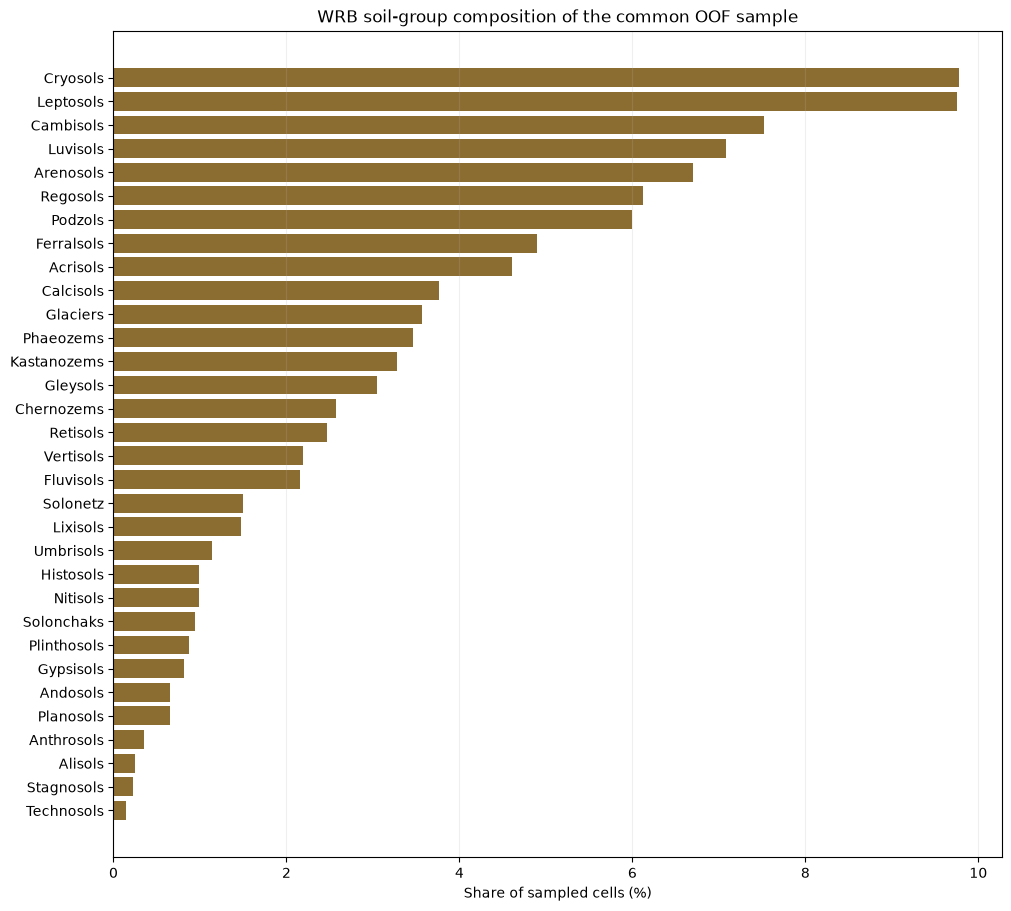

In [5]:
SOIL_LABELS = {
    1: "Acrisols", 2: "Alisols", 3: "Andosols", 4: "Arenosols",
    5: "Anthrosols", 6: "Chernozems", 7: "Calcisols", 8: "Cambisols",
    9: "Cryosols", 10: "Fluvisols", 11: "Ferralsols", 12: "Glaciers",
    13: "Gleysols", 14: "Gypsisols", 15: "Histosols", 16: "Islands",
    17: "Kastanozems", 18: "Leptosols", 19: "Luvisols", 20: "Lixisols",
    21: "Nitisols", 22: "Phaeozems", 23: "Planosols", 24: "Plinthosols",
    25: "Podzols", 26: "Regosols", 27: "Retisols", 28: "Solonchaks",
    29: "Solonetz", 30: "Stagnosols", 31: "Technosols", 32: "Umbrisols",
    33: "Vertisols", 34: "Open Water",
}

soil_codes = sample["soil_group_class"].astype(int)
soil_distribution = (
    soil_codes.value_counts()
    .sort_index()
    .rename_axis("soil_group_class")
    .reset_index(name="n")
)
soil_distribution["soil_group"] = soil_distribution["soil_group_class"].map(SOIL_LABELS)
soil_distribution["share_percent"] = 100 * soil_distribution["n"] / soil_distribution["n"].sum()
display(soil_distribution[["soil_group_class", "soil_group", "n", "share_percent"]].round(3))

technosol_n = int((soil_codes == 31).sum())
print("Technosol sample rows:", f"{technosol_n:,}")
print("Permanent-wetland sample rows:", int((sample["exclusion_class"].astype(int) == 5).sum()))

plot_frame = soil_distribution.sort_values("share_percent")
fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
ax.barh(
    plot_frame["soil_group"],
    plot_frame["share_percent"],
    color="#8C6D31",
)
ax.set_title("WRB soil-group composition of the common OOF sample")
ax.set_xlabel("Share of sampled cells (%)")
ax.grid(axis="x", alpha=0.2)
plt.show()


## 6. 二段階LightGBM・評価・SHAP関数

In [6]:
def adjust_probability_prior_shift(
    probability,
    sample_prior,
    population_prior,
    eps=1e-6,
):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    population_prior = float(np.clip(population_prior, eps, 1 - eps))
    odds = probability / (1.0 - probability)
    odds *= (
        (population_prior / (1.0 - population_prior))
        / (sample_prior / (1.0 - sample_prior))
    )
    return odds / (1.0 + odds)


def regression_metrics(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]

    residual = y_true - y_pred
    observed_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * residual ** 2)
    ss_tot = np.sum(weights * (y_true - observed_mean) ** 2)

    return {
        "n": int(len(y_true)),
        "observed_mean": float(observed_mean),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "rmse": float(np.sqrt(np.average(residual ** 2, weights=weights))),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "bias_observed_minus_predicted": float(np.average(residual, weights=weights)),
    }


def categorical_features_for(features):
    return [
        feature
        for feature in CATEGORICAL_CANDIDATES
        if feature in features
    ]


def fit_models(train_df, features, fold_number):
    categorical_features = categorical_features_for(features)

    classifier = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    classifier.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=categorical_features,
    )

    positive_train = train_df[train_df["presence"].eq(1)]
    regressor = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    regressor.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=categorical_features,
    )
    return classifier, regressor


def extract_tree_shap(explainer, values):
    shap_values = explainer.shap_values(values)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    if shap_values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")
    return shap_values


def select_local_positions(n_rows, max_rows, seed):
    if n_rows <= max_rows:
        return np.arange(n_rows, dtype=int)
    local_rng = np.random.default_rng(seed)
    return np.sort(
        local_rng.choice(n_rows, max_rows, replace=False)
    )


def add_shap_summaries(
    output_rows,
    model_name,
    stage,
    fold_number,
    features,
    shap_values,
    weights,
):
    weights = np.asarray(weights, dtype=float)
    valid_weight = np.isfinite(weights) & (weights > 0)
    if not valid_weight.any():
        weights = np.ones(len(shap_values), dtype=float)
        valid_weight = np.ones(len(shap_values), dtype=bool)

    shap_values = shap_values[valid_weight]
    weights = weights[valid_weight]
    for feature_index, feature in enumerate(features):
        values = shap_values[:, feature_index]
        output_rows.append({
            "model": model_name,
            "stage": stage,
            "fold": fold_number,
            "feature": feature,
            "sum_weight": float(weights.sum()),
            "sum_abs_shap_weighted": float(np.sum(weights * np.abs(values))),
            "sum_signed_shap_weighted": float(np.sum(weights * values)),
            "n": int(len(values)),
        })


## 窒素・リン・GDP追加モデルのSpatial OOF分析

target2020の既存準備コードを使い、窒素・リン・GDPを追加したモデルをbaselineと比較する。


## 追加データ可視化

追加データの基本統計


,variable,unit,n_valid,minimum,p01,median,mean,p99,maximum
0,Nitrogen,kg N / ha of grid-cell area,2102112,0.0000,0.0000,0.0449,4.8497,70.1381,216.5506
1,Phosphorus,kg P / ha of grid-cell area,2102112,0.0000,0.0000,0.0069,0.9822,14.2167,96.3830
2,GDP per capita,PPP 2017 international USD per person,2272228,245.8631,648.5423,19452.8086,30127.3106,212658.8906,723235.7500


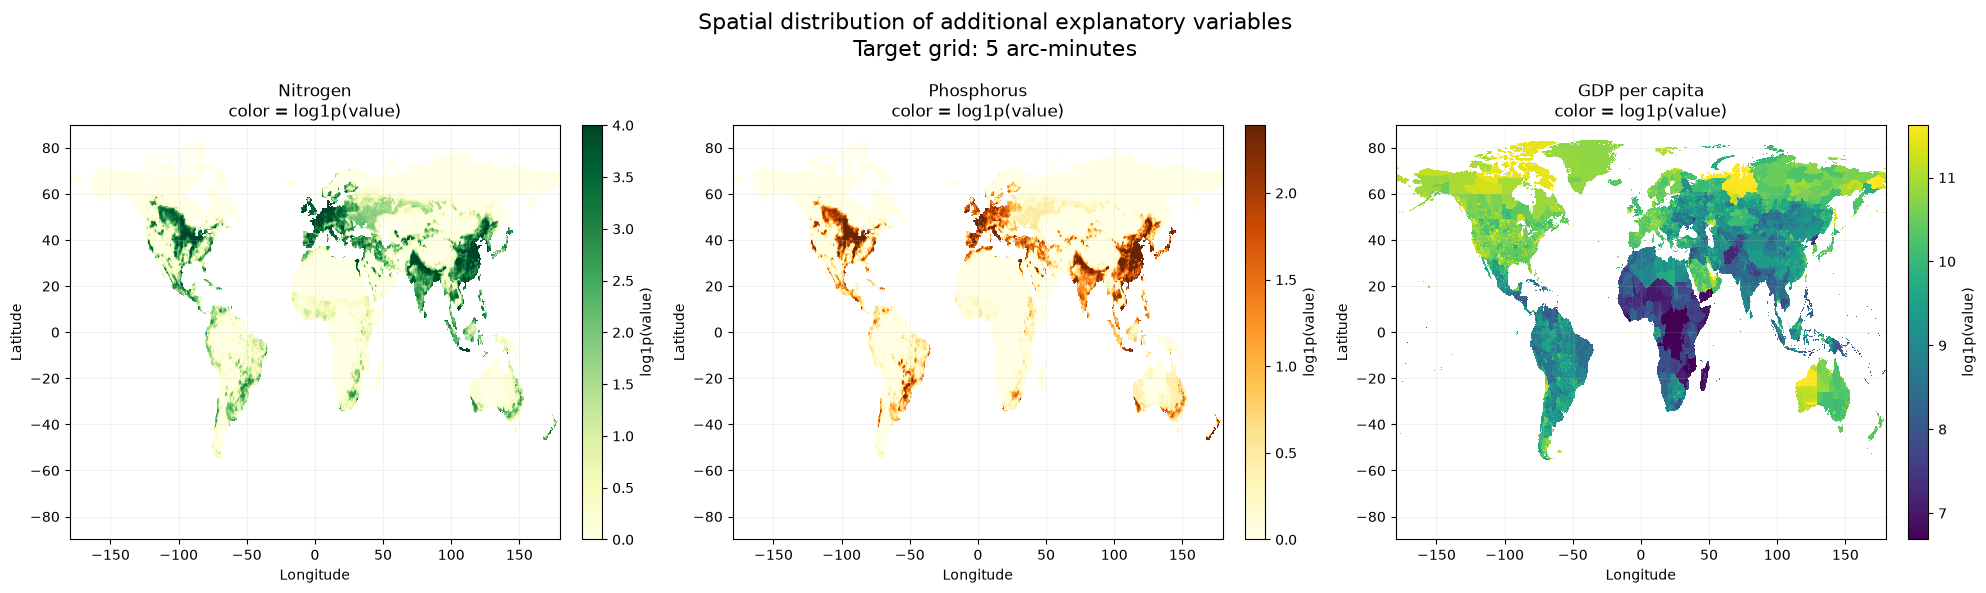

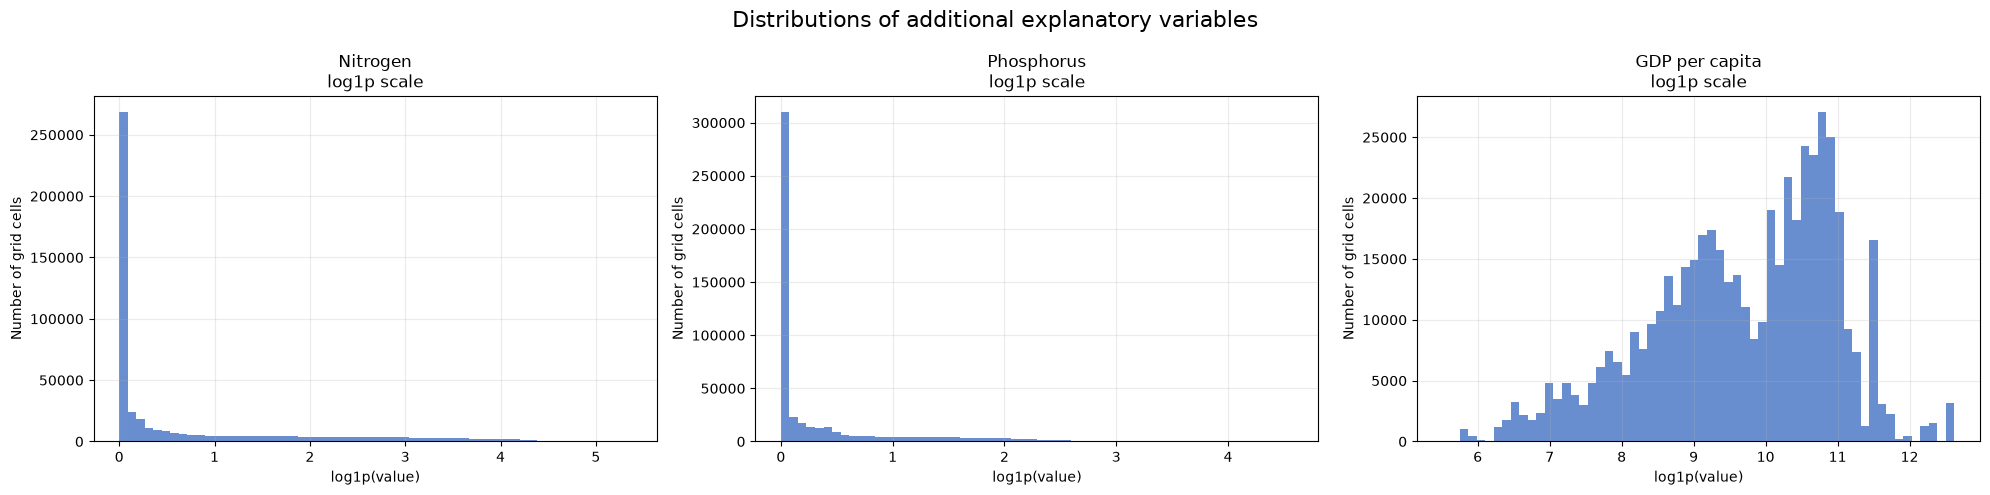

モデル投入値の統計


,variable,n,minimum,median,mean,maximum
0,log_nitrogen_fertilizer_kg_ha,224661,0.0000,0.1928,0.9280,5.3523
1,log_phosphorus_fertilizer_kg_ha,224661,0.0000,0.0441,0.4464,4.4510
2,log_gdp_pc_2020_ppp2017usd,224661,5.5109,9.5340,9.4792,12.6953


可視化が完了しました。


In [10]:
# ============================================================
# 追加データ（窒素・リン・GDP）の可視化
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 必要な変数の確認
# ------------------------------------------------------------

required_objects = [
    "nitrogen_kg_ha",
    "phosphorus_kg_ha",
    "gdp_2020",
    "lat",
    "lon",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "先に窒素・リン・GDPの読み込みセルを実行してください。\n"
        f"不足している変数: {missing_objects}"
    )


# ------------------------------------------------------------
# 2. データ定義
# ------------------------------------------------------------

data_specs = {
    "Nitrogen": {
        "array": nitrogen_kg_ha,
        "unit": "kg N / ha of grid-cell area",
        "cmap": "YlGn",
    },
    "Phosphorus": {
        "array": phosphorus_kg_ha,
        "unit": "kg P / ha of grid-cell area",
        "cmap": "YlOrBr",
    },
    "GDP per capita": {
        "array": gdp_2020,
        "unit": "PPP 2017 international USD per person",
        "cmap": "viridis",
    },
}


# ------------------------------------------------------------
# 3. 配列・緯度経度の確認
# ------------------------------------------------------------

target_lat = np.asarray(
    lat,
    dtype=float,
)

target_lon = np.asarray(
    lon,
    dtype=float,
)

target_shape = (
    len(target_lat),
    len(target_lon),
)

for name, spec in data_specs.items():

    array = np.asarray(
        spec["array"],
        dtype=float,
    )

    if array.shape != target_shape:
        raise ValueError(
            f"{name}のshapeがtarget gridと一致しません。\n"
            f"data: {array.shape}\n"
            f"target: {target_shape}"
        )

    spec["array"] = array


# ------------------------------------------------------------
# 4. 基本統計
# ------------------------------------------------------------

statistics_rows = []

for name, spec in data_specs.items():

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
        & (values >= 0)
    ]

    if len(finite_values) == 0:
        continue

    statistics_rows.append({
        "variable": name,
        "unit": spec["unit"],
        "n_valid": len(finite_values),
        "minimum": np.nanmin(finite_values),
        "p01": np.nanpercentile(finite_values, 1),
        "median": np.nanmedian(finite_values),
        "mean": np.nanmean(finite_values),
        "p99": np.nanpercentile(finite_values, 99),
        "maximum": np.nanmax(finite_values),
    })

statistics_table = pd.DataFrame(
    statistics_rows
)

print("追加データの基本統計")
display(
    statistics_table.round(4)
)


# ------------------------------------------------------------
# 5. log1p変換
# ------------------------------------------------------------

def make_log_array(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    values = np.where(
        np.isfinite(values)
        & (values >= 0),
        values,
        np.nan,
    )

    return np.log1p(values)


# 緯度の並びに応じて画像の上下を調整
if target_lat[0] > target_lat[-1]:
    image_origin = "upper"
else:
    image_origin = "lower"

image_extent = [
    float(np.nanmin(target_lon)),
    float(np.nanmax(target_lon)),
    float(np.nanmin(target_lat)),
    float(np.nanmax(target_lat)),
]


# ------------------------------------------------------------
# 6. 空間分布図
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
)

for ax, (name, spec) in zip(
    axes,
    data_specs.items(),
):

    log_array = make_log_array(
        spec["array"]
    )

    finite_values = log_array[
        np.isfinite(log_array)
    ]

    if len(finite_values) == 0:
        raise RuntimeError(
            f"{name}に有効な値がありません。"
        )

    # 極端な外れ値の影響を抑える
    vmin = float(
        np.nanpercentile(
            finite_values,
            2,
        )
    )

    vmax = float(
        np.nanpercentile(
            finite_values,
            98,
        )
    )

    image = ax.imshow(
        log_array,
        origin=image_origin,
        extent=image_extent,
        cmap=spec["cmap"],
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        f"{name}\n"
        "color = log1p(value)"
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.grid(
        alpha=0.25,
        linewidth=0.5,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label(
        "log1p(value)"
    )

fig.suptitle(
    "Spatial distribution of additional explanatory variables\n"
    "Target grid: 5 arc-minutes",
    fontsize=16,
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# 7. 値の分布図
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
)

for ax, (name, spec) in zip(
    axes,
    data_specs.items(),
):

    log_values = make_log_array(
        spec["array"]
    )

    log_values = log_values[
        np.isfinite(log_values)
    ]

    # 大きすぎる場合は描画用にサンプリング
    if len(log_values) > 500_000:

        rng = np.random.default_rng(
            RANDOM_SEED
            if "RANDOM_SEED" in globals()
            else 42
        )

        sample_index = rng.choice(
            len(log_values),
            size=500_000,
            replace=False,
        )

        log_values_for_plot = (
            log_values[sample_index]
        )

    else:

        log_values_for_plot = log_values

    ax.hist(
        log_values_for_plot,
        bins=60,
        color="#4472C4",
        alpha=0.8,
    )

    ax.set_title(
        f"{name}\n"
        "log1p scale"
    )

    ax.set_xlabel(
        "log1p(value)"
    )

    ax.set_ylabel(
        "Number of grid cells"
    )

    ax.grid(
        alpha=0.25,
    )

fig.suptitle(
    "Distributions of additional explanatory variables",
    fontsize=16,
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# 8. モデルに実際に投入する値の確認
# ------------------------------------------------------------

if "work" in globals():

    model_columns = [
        "log_nitrogen_fertilizer_kg_ha",
        "log_phosphorus_fertilizer_kg_ha",
        "log_gdp_pc_2020_ppp2017usd",
    ]

    available_columns = [
        column
        for column in model_columns
        if column in work.columns
    ]

    if available_columns:

        print(
            "モデル投入値の統計"
        )

        model_statistics = []

        for column in available_columns:

            values = pd.to_numeric(
                work[column],
                errors="coerce",
            ).to_numpy(
                dtype=float
            )

            values = values[
                np.isfinite(values)
            ]

            model_statistics.append({
                "variable": column,
                "n": len(values),
                "minimum": np.nanmin(values),
                "median": np.nanmedian(values),
                "mean": np.nanmean(values),
                "maximum": np.nanmax(values),
            })

        display(
            pd.DataFrame(
                model_statistics
            ).round(4)
        )

    else:

        print(
            "workにはモデル投入後の変数がまだありません。"
        )

else:

    print(
        "workはまだ作成されていません。"
        "上の空間分布図と全体分布図のみ作成しました。"
    )


print(
    "可視化が完了しました。"
)

## 対数化しない形での追加データ（リン窒素GDP）可視化

raw値の基本統計


,variable,unit,n_valid,minimum,p01,median,mean,p99,maximum
0,Nitrogen,kg N / ha of grid-cell area,2102112,0.0000,0.0000,0.0449,4.8497,70.1381,216.5506
1,Phosphorus,kg P / ha of grid-cell area,2102112,0.0000,0.0000,0.0069,0.9822,14.2167,96.3830
2,GDP per capita,PPP 2017 international USD per person,2272228,245.8631,648.5423,19452.8086,30127.3106,212658.8906,723235.7500


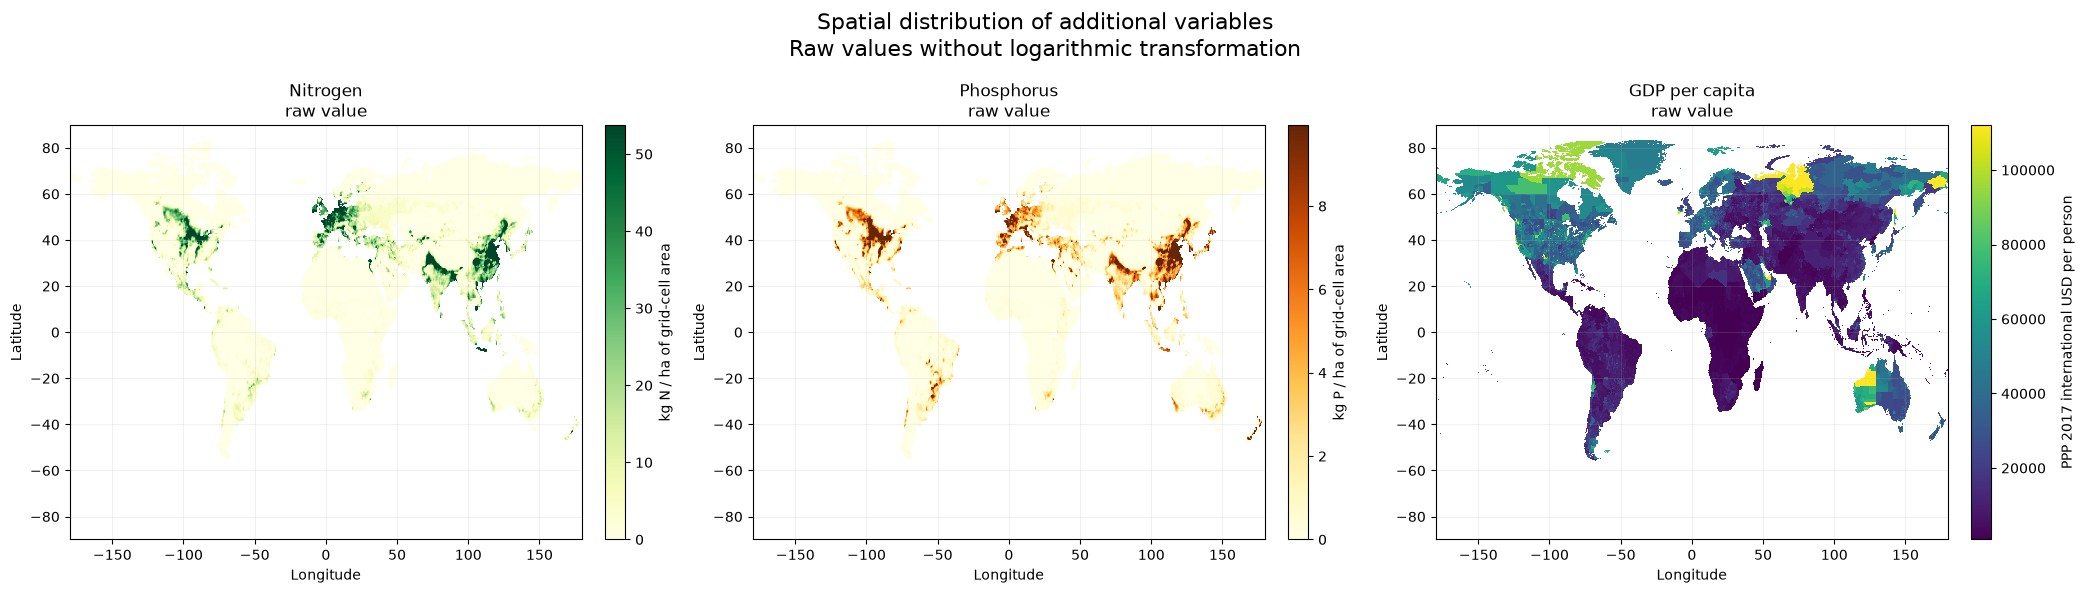

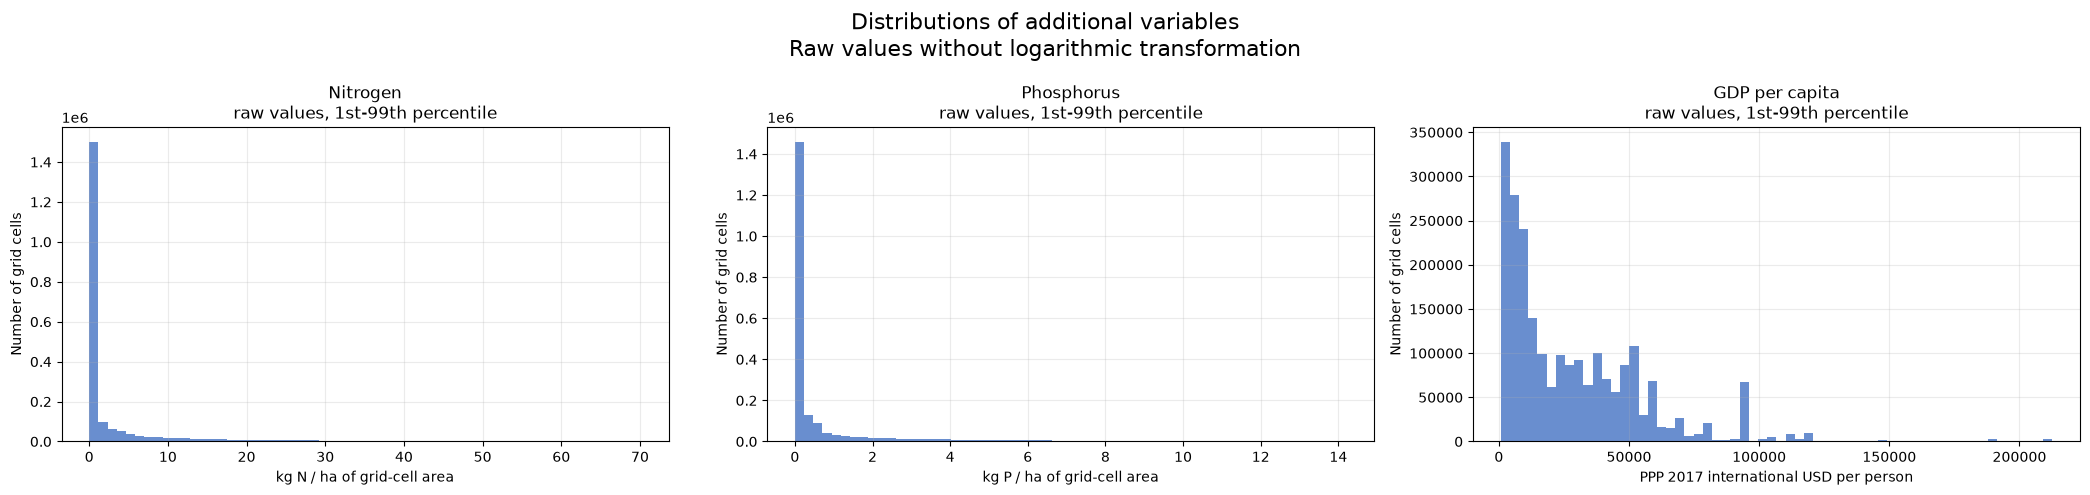

0の割合


,variable,zero_count,zero_share,valid_count
0,Nitrogen,782910,0.3724,2102112
1,Phosphorus,860337,0.4093,2102112
2,GDP per capita,0,0.0000,2272228


raw値による可視化が完了しました。


In [11]:
# ============================================================
# 窒素・リン・GDPのraw値による可視化
# 対数変換なし
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 必要な変数の確認
# ------------------------------------------------------------

required_objects = [
    "nitrogen_kg_ha",
    "phosphorus_kg_ha",
    "gdp_2020",
    "lat",
    "lon",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "先にデータ読み込みセルを実行してください。\n"
        f"不足している変数: {missing_objects}"
    )


# ------------------------------------------------------------
# 2. データ定義
# ------------------------------------------------------------

data_specs = {
    "Nitrogen": {
        "array": np.asarray(
            nitrogen_kg_ha,
            dtype=float,
        ),
        "unit": "kg N / ha of grid-cell area",
        "cmap": "YlGn",
    },
    "Phosphorus": {
        "array": np.asarray(
            phosphorus_kg_ha,
            dtype=float,
        ),
        "unit": "kg P / ha of grid-cell area",
        "cmap": "YlOrBr",
    },
    "GDP per capita": {
        "array": np.asarray(
            gdp_2020,
            dtype=float,
        ),
        "unit": "PPP 2017 international USD per person",
        "cmap": "viridis",
    },
}


target_lat = np.asarray(
    lat,
    dtype=float,
)

target_lon = np.asarray(
    lon,
    dtype=float,
)

target_shape = (
    len(target_lat),
    len(target_lon),
)


# ------------------------------------------------------------
# 3. shape確認と負値の除外
# ------------------------------------------------------------

for name, spec in data_specs.items():

    if spec["array"].shape != target_shape:
        raise ValueError(
            f"{name}のshapeが一致しません。\n"
            f"data: {spec['array'].shape}\n"
            f"target: {target_shape}"
        )

    spec["array"] = np.where(
        np.isfinite(spec["array"])
        & (spec["array"] >= 0),
        spec["array"],
        np.nan,
    )


# ------------------------------------------------------------
# 4. raw値の基本統計
# ------------------------------------------------------------

statistics_rows = []

for name, spec in data_specs.items():

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
    ]

    if len(finite_values) == 0:
        continue

    statistics_rows.append({
        "variable": name,
        "unit": spec["unit"],
        "n_valid": len(finite_values),
        "minimum": np.nanmin(finite_values),
        "p01": np.nanpercentile(
            finite_values,
            1,
        ),
        "median": np.nanmedian(
            finite_values
        ),
        "mean": np.nanmean(
            finite_values
        ),
        "p99": np.nanpercentile(
            finite_values,
            99,
        ),
        "maximum": np.nanmax(
            finite_values
        ),
    })


statistics_table_raw = pd.DataFrame(
    statistics_rows
)

print("raw値の基本統計")

display(
    statistics_table_raw.round(4)
)


# ------------------------------------------------------------
# 5. 緯度経度の表示設定
# ------------------------------------------------------------

if target_lat[0] > target_lat[-1]:
    image_origin = "upper"
else:
    image_origin = "lower"

image_extent = [
    float(np.nanmin(target_lon)),
    float(np.nanmax(target_lon)),
    float(np.nanmin(target_lat)),
    float(np.nanmax(target_lat)),
]


# ------------------------------------------------------------
# 6. raw値の空間分布図
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6),
)

for ax, (name, spec) in zip(
    axes,
    data_specs.items(),
):

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
    ]

    if len(finite_values) == 0:
        raise RuntimeError(
            f"{name}に有効な値がありません。"
        )

    # 外れ値の影響を抑えるため、
    # 色の範囲だけ2〜98パーセンタイルに制限する
    vmin = float(
        np.nanpercentile(
            finite_values,
            2,
        )
    )

    vmax = float(
        np.nanpercentile(
            finite_values,
            98,
        )
    )

    image = ax.imshow(
        values,
        origin=image_origin,
        extent=image_extent,
        cmap=spec["cmap"],
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        f"{name}\n"
        "raw value"
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.grid(
        alpha=0.25,
        linewidth=0.5,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label(
        spec["unit"]
    )


fig.suptitle(
    "Spatial distribution of additional variables\n"
    "Raw values without logarithmic transformation",
    fontsize=16,
)

fig.tight_layout()

if "OUTPUT_DIR_NPGDP" in globals():

    fig.savefig(
        OUTPUT_DIR_NPGDP
        / "additional_variables_raw_maps.png",
        dpi=250,
        bbox_inches="tight",
    )

plt.show()


# ------------------------------------------------------------
# 7. raw値のヒストグラム
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 5),
)

for ax, (name, spec) in zip(
    axes,
    data_specs.items(),
):

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
    ]

    if len(finite_values) == 0:
        continue

    # ヒストグラムは1〜99パーセンタイルの範囲を表示
    # 最大値などの外れ値は基本統計表で確認できる
    p01 = np.nanpercentile(
        finite_values,
        1,
    )

    p99 = np.nanpercentile(
        finite_values,
        99,
    )

    histogram_values = finite_values[
        (finite_values >= p01)
        & (finite_values <= p99)
    ]

    ax.hist(
        histogram_values,
        bins=60,
        color="#4472C4",
        alpha=0.8,
    )

    ax.set_title(
        f"{name}\n"
        "raw values, 1st-99th percentile"
    )

    ax.set_xlabel(
        spec["unit"]
    )

    ax.set_ylabel(
        "Number of grid cells"
    )

    ax.grid(
        alpha=0.25,
    )


fig.suptitle(
    "Distributions of additional variables\n"
    "Raw values without logarithmic transformation",
    fontsize=16,
)

fig.tight_layout()

if "OUTPUT_DIR_NPGDP" in globals():

    fig.savefig(
        OUTPUT_DIR_NPGDP
        / "additional_variables_raw_histograms.png",
        dpi=250,
        bbox_inches="tight",
    )

plt.show()


# ------------------------------------------------------------
# 8. 0の割合を確認
# ------------------------------------------------------------

zero_rows = []

for name, spec in data_specs.items():

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
    ]

    zero_rows.append({
        "variable": name,
        "zero_count": int(
            np.sum(finite_values == 0)
        ),
        "zero_share": float(
            np.mean(finite_values == 0)
        ),
        "valid_count": len(finite_values),
    })

zero_table = pd.DataFrame(
    zero_rows
)

print("0の割合")

display(
    zero_table.round(4)
)


print(
    "raw値による可視化が完了しました。"
)

In [ ]:
# ============================================================
# 窒素・リンはraw値、GDPはlog1pで扱う
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 必要な変数の確認
# ------------------------------------------------------------

required_objects = [
    "nitrogen_kg_ha",
    "phosphorus_kg_ha",
    "gdp_2020",
    "lat",
    "lon",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "先にデータ読み込みセルを実行してください。\n"
        f"不足している変数: {missing_objects}"
    )


# ------------------------------------------------------------
# 2. データの整形
# ------------------------------------------------------------

target_lat = np.asarray(
    lat,
    dtype=float,
)

target_lon = np.asarray(
    lon,
    dtype=float,
)

target_shape = (
    len(target_lat),
    len(target_lon),
)


def clean_nonnegative(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return np.where(
        np.isfinite(values)
        & (values >= 0),
        values,
        np.nan,
    )


def log_nonnegative(values):
    values = clean_nonnegative(values)
    return np.log1p(values)


nitrogen_raw = clean_nonnegative(
    nitrogen_kg_ha
)

phosphorus_raw = clean_nonnegative(
    phosphorus_kg_ha
)

gdp_raw = clean_nonnegative(
    gdp_2020
)

gdp_log = log_nonnegative(
    gdp_2020
)


for name, array in {
    "nitrogen_raw": nitrogen_raw,
    "phosphorus_raw": phosphorus_raw,
    "gdp_raw": gdp_raw,
}.items():

    if array.shape != target_shape:
        raise ValueError(
            f"{name}のshapeが一致しません。\n"
            f"data: {array.shape}\n"
            f"target: {target_shape}"
        )


# ------------------------------------------------------------
# 3. モデル用の説明変数を作成
# ------------------------------------------------------------

if "sample" not in globals():
    raise RuntimeError(
        "sampleがありません。target2020の準備セルを先に実行してください。"
    )


if "work" not in globals():
    work = sample.copy()


sample_rows = work[
    "row"
].to_numpy(
    dtype=int
)

sample_cols = work[
    "col"
].to_numpy(
    dtype=int
)


# 窒素・リン：raw値
work[
    "nitrogen_fertilizer_kg_ha"
] = nitrogen_raw[
    sample_rows,
    sample_cols,
]

work[
    "phosphorus_fertilizer_kg_ha"
] = phosphorus_raw[
    sample_rows,
    sample_cols,
]


# GDP：log1p値
work[
    "log_gdp_pc_2020_ppp2017usd"
] = gdp_log[
    sample_rows,
    sample_cols,
]


# ------------------------------------------------------------
# 4. モデルの説明変数を更新
# ------------------------------------------------------------

if "MODEL_FEATURES" in globals():

    baseline_features = list(
        MODEL_FEATURES[
            "soil_group_wetland_excluded"
        ]
    )

    added_features = [
        "nitrogen_fertilizer_kg_ha",
        "phosphorus_fertilizer_kg_ha",
        "log_gdp_pc_2020_ppp2017usd",
    ]

    augmented_features = (
        baseline_features
        + added_features
    )

    model_specs = {
        "baseline": baseline_features,
        "plus_raw_fertilizer_log_gdp": (
            augmented_features
        ),
    }

    print(
        "モデル説明変数を更新しました。"
    )

    print(
        "追加変数:",
        added_features,
    )

else:

    print(
        "MODEL_FEATURESがないため、"
        "モデル設定は更新していません。"
    )


# ------------------------------------------------------------
# 5. 可視化するデータ
# ------------------------------------------------------------

data_specs = {
    "Nitrogen fertilizer": {
        "array": nitrogen_raw,
        "unit": "kg N / ha of grid-cell area",
        "cmap": "YlGn",
        "scale": "raw",
    },
    "Phosphorus fertilizer": {
        "array": phosphorus_raw,
        "unit": "kg P / ha of grid-cell area",
        "cmap": "YlOrBr",
        "scale": "raw",
    },
    "GDP per capita": {
        "array": gdp_log,
        "unit": "log1p(PPP 2017 international USD/person)",
        "cmap": "viridis",
        "scale": "log1p",
    },
}


# ------------------------------------------------------------
# 6. 基本統計
# ------------------------------------------------------------

statistics_rows = []

for name, spec in data_specs.items():

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
    ]

    if len(finite_values) == 0:
        continue

    statistics_rows.append({
        "variable": name,
        "display_scale": spec["scale"],
        "unit": spec["unit"],
        "n_valid": len(finite_values),
        "minimum": np.nanmin(finite_values),
        "p01": np.nanpercentile(
            finite_values,
            1,
        ),
        "median": np.nanmedian(
            finite_values
        ),
        "mean": np.nanmean(
            finite_values
        ),
        "p99": np.nanpercentile(
            finite_values,
            99,
        ),
        "maximum": np.nanmax(
            finite_values
        ),
    })


statistics_table = pd.DataFrame(
    statistics_rows
)

print(
    "可視化スケールでの基本統計"
)

display(
    statistics_table.round(4)
)


# GDPのraw値も別に表示
gdp_raw_values = gdp_raw[
    np.isfinite(gdp_raw)
]

gdp_raw_statistics = pd.DataFrame([{
    "variable": "GDP per capita raw",
    "unit": "PPP 2017 international USD/person",
    "n_valid": len(gdp_raw_values),
    "minimum": np.nanmin(gdp_raw_values),
    "p01": np.nanpercentile(
        gdp_raw_values,
        1,
    ),
    "median": np.nanmedian(
        gdp_raw_values
    ),
    "mean": np.nanmean(
        gdp_raw_values
    ),
    "p99": np.nanpercentile(
        gdp_raw_values,
        99,
    ),
    "maximum": np.nanmax(
        gdp_raw_values
    ),
}])

print(
    "GDPのraw値の統計"
)

display(
    gdp_raw_statistics.round(4)
)


# ------------------------------------------------------------
# 7. 地図の設定
# ------------------------------------------------------------

if target_lat[0] > target_lat[-1]:
    image_origin = "upper"
else:
    image_origin = "lower"

image_extent = [
    float(np.nanmin(target_lon)),
    float(np.nanmax(target_lon)),
    float(np.nanmin(target_lat)),
    float(np.nanmax(target_lat)),
]


# ------------------------------------------------------------
# 8. 空間分布図
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6),
)

for ax, (name, spec) in zip(
    axes,
    data_specs.items(),
):

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
    ]

    if len(finite_values) == 0:
        continue

    # 色の範囲は2〜98パーセンタイル
    # ただし、データ自体は加工していない
    vmin = float(
        np.nanpercentile(
            finite_values,
            2,
        )
    )

    vmax = float(
        np.nanpercentile(
            finite_values,
            98,
        )
    )

    image = ax.imshow(
        values,
        origin=image_origin,
        extent=image_extent,
        cmap=spec["cmap"],
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title(
        f"{name}\n"
        f"{spec['scale']}"
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.grid(
        alpha=0.25,
        linewidth=0.5,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label(
        spec["unit"]
    )


fig.suptitle(
    "Additional explanatory variables\n"
    "Raw fertilizer inputs and log-transformed GDP",
    fontsize=16,
)

fig.tight_layout()

if "OUTPUT_DIR_NPGDP" in globals():

    fig.savefig(
        OUTPUT_DIR_NPGDP
        / "fertilizer_raw_gdp_log_maps.png",
        dpi=250,
        bbox_inches="tight",
    )

plt.show()


# ------------------------------------------------------------
# 9. ヒストグラム
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 5),
)

for ax, (name, spec) in zip(
    axes,
    data_specs.items(),
):

    values = spec["array"]

    finite_values = values[
        np.isfinite(values)
    ]

    if len(finite_values) == 0:
        continue

    p01 = np.nanpercentile(
        finite_values,
        1,
    )

    p99 = np.nanpercentile(
        finite_values,
        99,
    )

    histogram_values = finite_values[
        (finite_values >= p01)
        & (finite_values <= p99)
    ]

    ax.hist(
        histogram_values,
        bins=60,
        color="#4472C4",
        alpha=0.8,
    )

    ax.set_title(
        f"{name}\n"
        f"{spec['scale']}, 1st-99th percentile"
    )

    ax.set_xlabel(
        spec["unit"]
    )

    ax.set_ylabel(
        "Number of grid cells"
    )

    ax.grid(
        alpha=0.25,
    )


fig.suptitle(
    "Distributions of additional variables\n"
    "Raw fertilizer inputs and log-transformed GDP",
    fontsize=16,
)

fig.tight_layout()

if "OUTPUT_DIR_NPGDP" in globals():

    fig.savefig(
        OUTPUT_DIR_NPGDP
        / "fertilizer_raw_gdp_log_histograms.png",
        dpi=250,
        bbox_inches="tight",
    )

plt.show()


# ------------------------------------------------------------
# 10. 0の割合
# ------------------------------------------------------------

zero_rows = []

for name, array in {
    "Nitrogen fertilizer": nitrogen_raw,
    "Phosphorus fertilizer": phosphorus_raw,
    "GDP per capita": gdp_raw,
}.items():

    finite_values = array[
        np.isfinite(array)
    ]

    zero_rows.append({
        "variable": name,
        "zero_count": int(
            np.sum(finite_values == 0)
        ),
        "zero_share": float(
            np.mean(finite_values == 0)
        ),
        "valid_count": len(finite_values),
    })

zero_table = pd.DataFrame(
    zero_rows
)

print(
    "raw値における0の割合"
)

display(
    zero_table.round(4)
)


print(
    "窒素・リンはraw値、GDPはlog1p値で可視化・モデル設定しました。"
)

## 窒素、リン（肥料はraw、GDPは対数）追加して精度が実際に上がることを示す。

追加する説明変数: ['nitrogen_fertilizer_kg_ha', 'phosphorus_fertilizer_kg_ha', 'log_gdp_pc_2020_ppp2017usd']
分析対象セル数: 224,661
完全ケース保持率: 93.609%
OOF model: baseline
fold 1/5 開始
fold 1/5: R2=0.65235, RMSE=0.13353
fold 2/5 開始
fold 2/5: R2=0.64540, RMSE=0.12517
fold 3/5 開始
fold 3/5: R2=0.63988, RMSE=0.14070
fold 4/5 開始
fold 4/5: R2=0.66307, RMSE=0.14378
fold 5/5 開始
fold 5/5: R2=0.47345, RMSE=0.14236
OOF model: plus_raw_fertilizer_log_gdp
fold 1/5 開始
fold 1/5: R2=0.72049, RMSE=0.11973
fold 2/5 開始
fold 2/5: R2=0.71919, RMSE=0.11138
fold 3/5 開始
fold 3/5: R2=0.71144, RMSE=0.12594
fold 4/5 開始
fold 4/5: R2=0.73152, RMSE=0.12835
fold 5/5 開始
fold 5/5: R2=0.59176, RMSE=0.12535

OOF global metrics
                      model                weighting      n       r2     rmse      mae  bias_observed_minus_predicted
                   baseline        unweighted_sample 224661 0.626268 0.137282 0.078771                       0.013968
                   baseline area_weighted_reweighted 224661 0.619674 0.129419 0

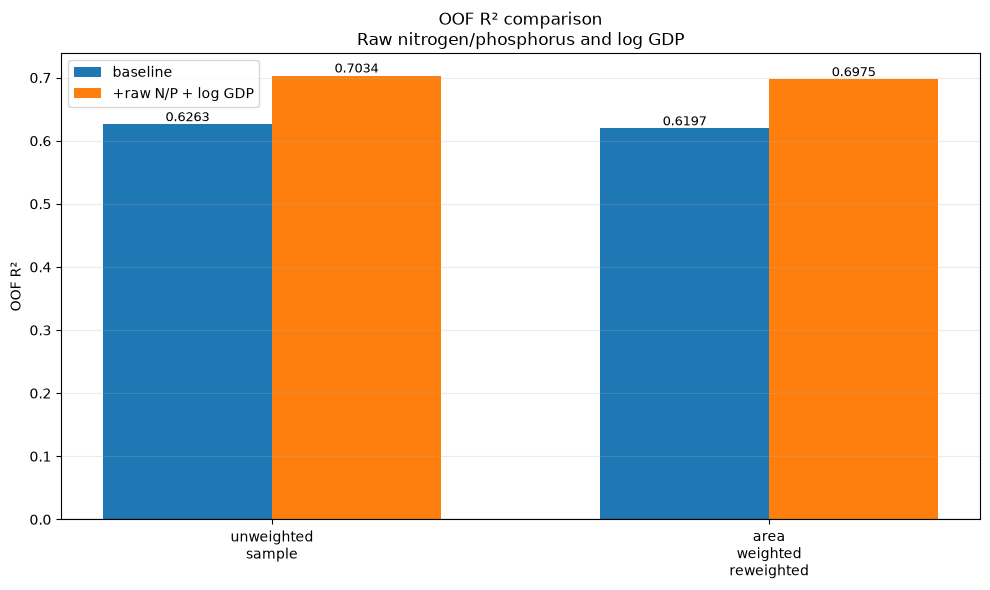

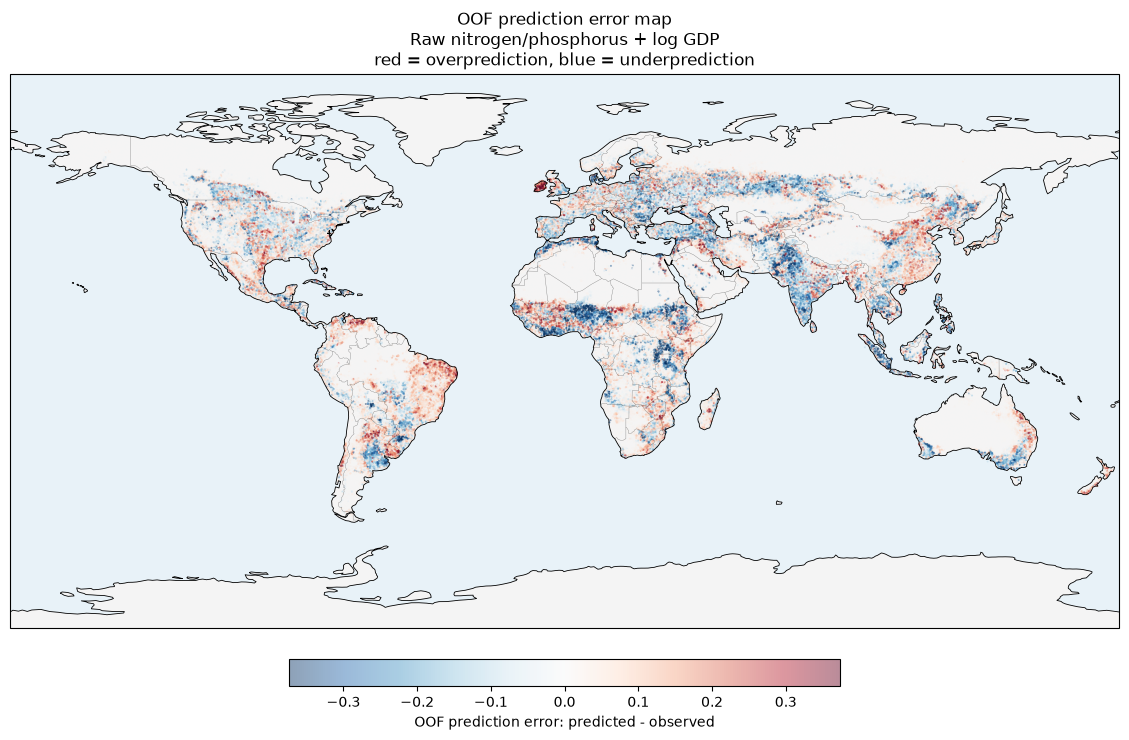


全処理が完了しました。
出力先: /work/tsuda/GAEZ/CroplandRegression/soil_group_nutrients_gdp_target2020


In [13]:
# ============================================================
# OOF分析
# 窒素・リン：raw値
# GDP：log1p
# 決定係数・誤差マップ
# ============================================================

import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 0. 必要な変数の確認
# ============================================================

required_objects = [
    "sample",
    "MODEL_FEATURES",
    "fit_models",
    "adjust_probability_prior_shift",
    "target_prior",
    "lat",
    "lon",
    "CATEGORICAL_CANDIDATES",
    "N_SPLITS",
    "RANDOM_SEED",
    "nitrogen_kg_ha",
    "phosphorus_kg_ha",
    "gdp_2020",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "target2020の準備セルとデータ読み込みセルを先に実行してください。\n"
        f"不足している変数: {missing_objects}"
    )


# ============================================================
# 1. 出力先
# ============================================================

OUTPUT_DIR_NPGDP = Path(
    "/work/tsuda/GAEZ/CroplandRegression/"
    "soil_group_nutrients_gdp_target2020"
)

OUTPUT_DIR_NPGDP.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. GDPのみlog1p変換
# ============================================================

def clean_nonnegative(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return np.where(
        np.isfinite(values)
        & (values >= 0),
        values,
        np.nan,
    )


def log_nonnegative(values):
    values = clean_nonnegative(values)

    return np.log1p(
        values
    ).astype(np.float32)


# ============================================================
# 3. sampleへ説明変数を追加
# ============================================================

work = sample.copy()

sample_rows = work[
    "row"
].to_numpy(
    dtype=int
)

sample_cols = work[
    "col"
].to_numpy(
    dtype=int
)


# 窒素：raw値
work[
    "nitrogen_fertilizer_kg_ha"
] = clean_nonnegative(
    nitrogen_kg_ha[
        sample_rows,
        sample_cols,
    ]
)


# リン：raw値
work[
    "phosphorus_fertilizer_kg_ha"
] = clean_nonnegative(
    phosphorus_kg_ha[
        sample_rows,
        sample_cols,
    ]
)


# GDP：log1p値
work[
    "log_gdp_pc_2020_ppp2017usd"
] = log_nonnegative(
    gdp_2020[
        sample_rows,
        sample_cols,
    ]
)


# ============================================================
# 4. モデルの説明変数
# ============================================================

baseline_features = list(
    MODEL_FEATURES[
        "soil_group_wetland_excluded"
    ]
)

added_features = [
    "nitrogen_fertilizer_kg_ha",
    "phosphorus_fertilizer_kg_ha",
    "log_gdp_pc_2020_ppp2017usd",
]

augmented_features = (
    baseline_features
    + added_features
)

model_specs = {
    "baseline": baseline_features,
    "plus_raw_fertilizer_log_gdp": (
        augmented_features
    ),
}

print(
    "追加する説明変数:",
    added_features,
)


# ============================================================
# 5. 完全ケース抽出
# ============================================================

needed_columns = list(
    dict.fromkeys(
        baseline_features
        + added_features
        + [
            "cropland_fraction",
            "presence",
            "spatial_block",
        ]
    )
)

valid_rows = np.ones(
    len(work),
    dtype=bool,
)

for column in needed_columns:

    if column in CATEGORICAL_CANDIDATES:

        valid_rows &= (
            work[column]
            .notna()
            .to_numpy()
        )

    else:

        numeric = pd.to_numeric(
            work[column],
            errors="coerce",
        ).to_numpy(
            dtype=float
        )

        valid_rows &= np.isfinite(
            numeric
        )


work = work.loc[
    valid_rows
].reset_index(
    drop=True
)


for column in CATEGORICAL_CANDIDATES:

    if column in work.columns:

        work[column] = work[
            column
        ].astype(
            "category"
        )


if len(work) == 0:
    raise RuntimeError(
        "完全ケースが0件です。"
    )

if work[
    "presence"
].nunique() != 2:
    raise RuntimeError(
        "presenceの完全ケースに両クラスがありません。"
    )


print(
    "分析対象セル数:",
    f"{len(work):,}",
)

print(
    "完全ケース保持率:",
    f"{len(work) / len(sample):.3%}",
)


# ============================================================
# 6. 空間GroupKFold
# ============================================================

groups = work[
    "spatial_block"
].to_numpy()

y_presence = work[
    "presence"
].to_numpy(
    dtype=np.uint8
)

oof_splits = list(
    GroupKFold(
        n_splits=N_SPLITS
    ).split(
        work,
        y_presence,
        groups=groups,
    )
)


# ============================================================
# 7. 面積重み
# ============================================================

# area_weightは説明変数を面積で割るためのものではない。
# OOF評価時の面積重み付きR2などにのみ使用する。

if (
    "area_weight" in globals()
    and area_weight is not None
):

    original_area_weight = np.asarray(
        area_weight,
        dtype=float,
    )

    if len(original_area_weight) != len(
        valid_rows
    ):
        raise ValueError(
            "area_weightとsampleの行数が一致しません。"
        )

    analysis_area_weight = (
        original_area_weight[
            valid_rows
        ]
    )

    analysis_area_weight[
        ~np.isfinite(
            analysis_area_weight
        )
    ] = 0.0

    analysis_area_weight[
        analysis_area_weight < 0
    ] = 0.0

else:

    analysis_area_weight = None


# ============================================================
# 8. 評価関数
# ============================================================

def local_metrics(
    y_true,
    y_pred,
    weights=None,
):

    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    valid = (
        np.isfinite(y_true)
        & np.isfinite(y_pred)
    )

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if weights is None:

        weights = np.ones(
            len(y_true),
            dtype=float,
        )

    else:

        weights = np.asarray(
            weights,
            dtype=float,
        )[valid]

    valid_weights = (
        np.isfinite(weights)
        & (weights > 0)
    )

    y_true = y_true[
        valid_weights
    ]

    y_pred = y_pred[
        valid_weights
    ]

    weights = weights[
        valid_weights
    ]

    if len(y_true) == 0:
        return {
            "n": 0,
            "r2": np.nan,
            "rmse": np.nan,
            "mae": np.nan,
            "bias_observed_minus_predicted": np.nan,
        }

    residual = y_true - y_pred

    observed_mean = np.average(
        y_true,
        weights=weights,
    )

    ss_res = np.sum(
        weights * residual**2
    )

    ss_tot = np.sum(
        weights
        * (y_true - observed_mean)**2
    )

    return {
        "n": int(len(y_true)),
        "r2": float(
            1.0 - ss_res / ss_tot
        )
        if ss_tot > 0
        else np.nan,
        "rmse": float(
            np.sqrt(
                np.average(
                    residual**2,
                    weights=weights,
                )
            )
        ),
        "mae": float(
            np.average(
                np.abs(residual),
                weights=weights,
            )
        ),
        "bias_observed_minus_predicted": float(
            np.average(
                residual,
                weights=weights,
            )
        ),
    }


# ============================================================
# 9. OOF予測
# ============================================================

prediction_by_model = {}
fold_rows = []


for model_name, features in (
    model_specs.items()
):

    print("=" * 80)
    print("OOF model:", model_name)
    print("=" * 80)

    expected_oof = np.full(
        len(work),
        np.nan,
        dtype=np.float32,
    )

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(
        oof_splits,
        start=1,
    ):

        print(
            f"fold {fold_number}/{N_SPLITS} 開始",
            flush=True,
        )

        train_df = work.iloc[
            train_idx
        ]

        test_df = work.iloc[
            test_idx
        ]

        classifier, regressor = fit_models(
            train_df,
            features,
            fold_number,
        )

        # 耕作地の有無
        raw_probability = (
            classifier.predict_proba(
                test_df[features]
            )[:, 1]
        )

        calibrated_probability = (
            adjust_probability_prior_shift(
                raw_probability,
                float(
                    train_df[
                        "presence"
                    ].mean()
                ),
                target_prior,
            )
        )

        # 耕作地割合
        conditional_fraction = np.clip(
            regressor.predict(
                test_df[features]
            ),
            0.0,
            1.0,
        )

        # 2段階統合
        expected_fraction = (
            calibrated_probability
            * conditional_fraction
        )

        expected_oof[
            test_idx
        ] = expected_fraction.astype(
            np.float32
        )

        y_test_presence = test_df[
            "presence"
        ].to_numpy(
            dtype=np.uint8
        )

        y_test_fraction = test_df[
            "cropland_fraction"
        ].to_numpy(
            dtype=float
        )

        fold_metric = local_metrics(
            y_test_fraction,
            expected_fraction,
        )

        if np.unique(
            y_test_presence
        ).size == 2:

            presence_auc = roc_auc_score(
                y_test_presence,
                raw_probability,
            )

            presence_average_precision = (
                average_precision_score(
                    y_test_presence,
                    raw_probability,
                )
            )

        else:

            presence_auc = np.nan
            presence_average_precision = np.nan

        fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "combined_r2": fold_metric["r2"],
            "combined_rmse": fold_metric["rmse"],
            "combined_mae": fold_metric["mae"],
            "presence_auc": presence_auc,
            "presence_average_precision": (
                presence_average_precision
            ),
        })

        print(
            f"fold {fold_number}/{N_SPLITS}: "
            f"R2={fold_metric['r2']:.5f}, "
            f"RMSE={fold_metric['rmse']:.5f}",
            flush=True,
        )

        del classifier
        del regressor

        gc.collect()

    if not np.isfinite(
        expected_oof
    ).all():

        raise RuntimeError(
            f"OOF予測が未完了です: {model_name}"
        )

    prediction_by_model[
        model_name
    ] = expected_oof


# ============================================================
# 10. 全体OOF決定係数
# ============================================================

weight_specs = {
    "unweighted_sample": None,
}

if (
    analysis_area_weight is not None
    and np.sum(
        analysis_area_weight > 0
    ) > 0
):

    weight_specs[
        "area_weighted_reweighted"
    ] = analysis_area_weight


observed = work[
    "cropland_fraction"
].to_numpy(
    dtype=float
)

global_rows = []


for model_name, prediction in (
    prediction_by_model.items()
):

    for weighting, weights in (
        weight_specs.items()
    ):

        metrics = local_metrics(
            observed,
            prediction,
            weights=weights,
        )

        global_rows.append({
            "model": model_name,
            "weighting": weighting,
            **metrics,
        })


fold_metrics_npgdp = pd.DataFrame(
    fold_rows
)

global_metrics_npgdp = pd.DataFrame(
    global_rows
)


print("\n==============================")
print("OOF global metrics")
print("==============================")

print(
    global_metrics_npgdp
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 11. 予測結果の保存
# ============================================================

prediction_table_npgdp = work[
    [
        "row",
        "col",
        "lat",
        "lon",
        "spatial_block",
        "presence",
        "cropland_fraction",
        "nitrogen_fertilizer_kg_ha",
        "phosphorus_fertilizer_kg_ha",
        "log_gdp_pc_2020_ppp2017usd",
        "exclusion_class",
        "soil_group_class",
    ]
].copy()


for model_name, prediction in (
    prediction_by_model.items()
):

    prediction_table_npgdp[
        f"pred_{model_name}"
    ] = prediction


hybrid_model_name = (
    "plus_raw_fertilizer_log_gdp"
)

prediction_table_npgdp[
    "oof_error_plus_raw_fertilizer_log_gdp"
] = (
    prediction_table_npgdp[
        f"pred_{hybrid_model_name}"
    ]
    - prediction_table_npgdp[
        "cropland_fraction"
    ]
)


global_metrics_npgdp.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_oof_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)


fold_metrics_npgdp.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_oof_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)


prediction_table_npgdp.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_oof_predictions.csv.gz",
    index=False,
    compression="gzip",
)


# ============================================================
# 12. 決定係数比較図
# ============================================================

plot_metrics = (
    global_metrics_npgdp.copy()
)

plot_metrics["label"] = (
    plot_metrics["model"].map({
        "baseline": "baseline",
        "plus_raw_fertilizer_log_gdp": (
            "+raw N/P + log GDP"
        ),
    })
)

weighting_order = [
    value
    for value in [
        "unweighted_sample",
        "area_weighted_reweighted",
    ]
    if value in (
        plot_metrics[
            "weighting"
        ].unique()
    )
]

model_order = [
    "baseline",
    "+raw N/P + log GDP",
]

x = np.arange(
    len(weighting_order)
)

width = 0.34

fig, ax = plt.subplots(
    figsize=(10, 6)
)


for model_index, model_label in (
    enumerate(model_order)
):

    values = []

    for weighting in weighting_order:

        row = plot_metrics[
            (
                plot_metrics["label"]
                == model_label
            )
            & (
                plot_metrics["weighting"]
                == weighting
            )
        ]

        values.append(
            float(
                row["r2"].iloc[0]
            )
        )

    bars = ax.bar(
        x
        + (
            model_index - 0.5
        ) * width,
        values,
        width,
        label=model_label,
    )

    for bar, value in zip(
        bars,
        values,
    ):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


ax.set_xticks(x)

ax.set_xticklabels([
    value.replace(
        "_",
        "\n",
    )
    for value in weighting_order
])

ax.set_ylabel(
    "OOF R²"
)

ax.set_title(
    "OOF R² comparison\n"
    "Raw nitrogen/phosphorus and log GDP"
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_oof_r2_comparison.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 13. OOF誤差マップ
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED + 9000
)


if len(
    prediction_table_npgdp
) > 120_000:

    map_idx = np.sort(
        rng.choice(
            len(
                prediction_table_npgdp
            ),
            size=120_000,
            replace=False,
        )
    )

else:

    map_idx = np.arange(
        len(
            prediction_table_npgdp
        )
    )


map_frame = (
    prediction_table_npgdp.iloc[
        map_idx
    ]
)

map_error = map_frame[
    "oof_error_plus_raw_fertilizer_log_gdp"
].to_numpy(
    dtype=float
)

finite_error = np.isfinite(
    map_error
)

if not finite_error.any():
    raise RuntimeError(
        "誤差マップを作成できる有効値がありません。"
    )


error_scale = float(
    np.nanpercentile(
        np.abs(
            map_error[
                finite_error
            ]
        ),
        98,
    )
)

error_scale = max(
    error_scale,
    1e-6,
)

norm = TwoSlopeNorm(
    vmin=-error_scale,
    vcenter=0.0,
    vmax=error_scale,
)


# ------------------------------------------------------------
# 13-1. Cartopyによる地図
# ------------------------------------------------------------

map_saved = False

try:

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(
        figsize=(15, 7.5)
    )

    ax = plt.axes(
        projection=ccrs.PlateCarree()
    )

    ax.set_global()

    ax.add_feature(
        cfeature.LAND,
        facecolor="#f4f4f4",
        zorder=0,
    )

    ax.add_feature(
        cfeature.OCEAN,
        facecolor="#e8f2f8",
        zorder=0,
    )

    ax.coastlines(
        linewidth=0.6
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.25,
        alpha=0.5,
    )

    scatter = ax.scatter(
        map_frame["lon"],
        map_frame["lat"],
        c=map_error,
        cmap="RdBu_r",
        norm=norm,
        s=2.0,
        alpha=0.45,
        linewidths=0,
        transform=ccrs.PlateCarree(),
    )

    # GEOSException回避のためgridlinesは使用しない
    ax.set_title(
        "OOF prediction error map\n"
        "Raw nitrogen/phosphorus + log GDP\n"
        "red = overprediction, blue = underprediction"
    )

    fig.colorbar(
        scatter,
        ax=ax,
        orientation="horizontal",
        pad=0.05,
        fraction=0.045,
        label=(
            "OOF prediction error: "
            "predicted - observed"
        ),
    )

    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR_NPGDP
        / "raw_fertilizer_log_gdp_oof_error_map.png",
        dpi=250,
        bbox_inches="tight",
    )

    map_saved = True

    plt.show()

except Exception as error:

    print(
        "Cartopy地図の保存に失敗しました。"
    )

    print(
        "平面図に切り替えます:"
    )

    print(
        repr(error)
    )

    plt.close("all")


# ------------------------------------------------------------
# 13-2. Cartopyが失敗した場合の平面図
# ------------------------------------------------------------

if not map_saved:

    fig, ax = plt.subplots(
        figsize=(15, 7.5)
    )

    ax.set_facecolor(
        "#e8f2f8"
    )

    scatter = ax.scatter(
        map_frame["lon"],
        map_frame["lat"],
        c=map_error,
        cmap="RdBu_r",
        norm=norm,
        s=2.0,
        alpha=0.45,
        linewidths=0,
    )

    ax.set_xlim(
        -180,
        180,
    )

    ax.set_ylim(
        -60,
        85,
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.grid(
        alpha=0.3,
    )

    ax.set_title(
        "OOF prediction error map\n"
        "Raw nitrogen/phosphorus + log GDP\n"
        "red = overprediction, blue = underprediction"
    )

    fig.colorbar(
        scatter,
        ax=ax,
        orientation="horizontal",
        pad=0.05,
        fraction=0.045,
        label=(
            "OOF prediction error: "
            "predicted - observed"
        ),
    )

    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR_NPGDP
        / "raw_fertilizer_log_gdp_oof_error_map.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


# ============================================================
# 14. 完了表示
# ============================================================

print("\n全処理が完了しました。")
print(
    "出力先:",
    OUTPUT_DIR_NPGDP,
)

## shap分析など

MSE・R2改善量


,weighting,baseline_r2,added_model_r2,r2_change,baseline_rmse,added_model_rmse,baseline_mse,added_model_mse,mse_reduction,mse_reduction_percent
0,area_weighted_reweighted,0.619674,0.697547,0.077873,0.129419,0.115412,0.016749,0.013320,0.003429,20.475303
1,unweighted_sample,0.626268,0.703375,0.077107,0.137282,0.122303,0.018846,0.014958,0.003888,20.631706


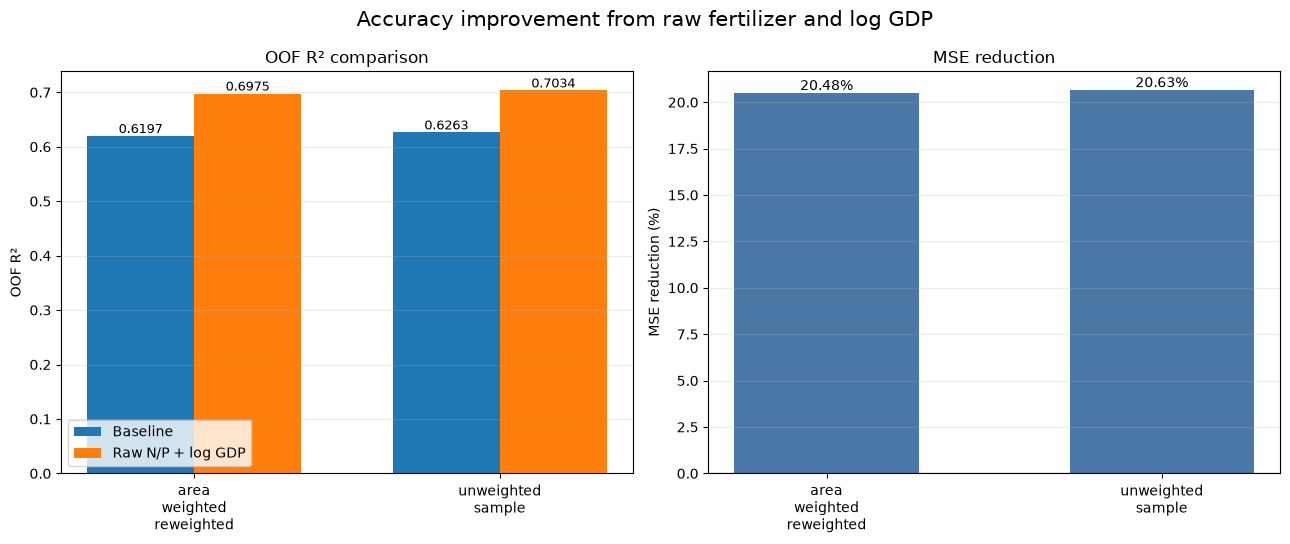

OOF SHAPの再計算を開始します。
SHAP model: baseline
fold 1/5


/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


fold 2/5


/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


fold 3/5


...

/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


追加変数のSHAP重要度


,model,stage,feature,mean_abs_shap,mean_signed_shap,relative_importance_share
30,plus_raw_fertilizer_log_gdp,conditional_fraction_regressor,nitrogen_fertilizer_kg_ha,0.066990,-0.010520,0.209350
27,plus_raw_fertilizer_log_gdp,conditional_fraction_regressor,log_gdp_pc_2020_ppp2017usd,0.029269,0.002844,0.091470
31,plus_raw_fertilizer_log_gdp,conditional_fraction_regressor,phosphorus_fertilizer_kg_ha,0.020836,0.002342,0.065114
44,plus_raw_fertilizer_log_gdp,presence_classifier,nitrogen_fertilizer_kg_ha,0.773845,-0.087413,0.146100
41,plus_raw_fertilizer_log_gdp,presence_classifier,log_gdp_pc_2020_ppp2017usd,0.276020,0.022954,0.052112
45,plus_raw_fertilizer_log_gdp,presence_classifier,phosphorus_fertilizer_kg_ha,0.123321,-0.017287,0.023283


共通変数のSHAP変化


,stage,feature,baseline_mean_abs_shap,baseline_mean_signed_shap,added_model_mean_abs_shap,added_model_mean_signed_shap,change_in_mean_abs_shap,change_in_mean_abs_shap_percent
11,conditional_fraction_regressor,slope,0.040412,0.000380,0.045610,0.001813,0.005198,12.863287
6,conditional_fraction_regressor,log_glofas_p10_2020,0.006984,-0.000346,0.004869,-0.000167,-0.002115,-30.284175
1,conditional_fraction_regressor,exclusion_class,0.027687,0.000532,0.024057,0.000670,-0.003629,-13.108827
10,conditional_fraction_regressor,rainfed_calorie_top5_raw,0.013116,-0.001162,0.008982,0.000695,-0.004134,-31.521061
7,conditional_fraction_regressor,log_port_time_any_min,0.014370,-0.000897,0.010037,-0.001793,-0.004333,-30.152813
4,conditional_fraction_regressor,log_distance_river_gt10_2020,0.008754,-0.001156,0.004248,-0.000355,-0.004506,-51.478137
0,conditional_fraction_regressor,elevation_m,0.023571,-0.003022,0.018628,-0.003001,-0.004943,-20.972342
2,conditional_fraction_regressor,irrigation_calorie_gain_top5_raw,0.019341,0.000270,0.013251,0.000519,-0.006090,-31.486190
13,conditional_fraction_regressor,wx_50km_rainfed_calorie_top5_raw,0.019026,-0.001185,0.007386,-0.000404,-0.011641,-61.182593
12,conditional_fraction_regressor,soil_group_class,0.044719,-0.007218,0.028932,-0.005527,-0.015787,-35.301979


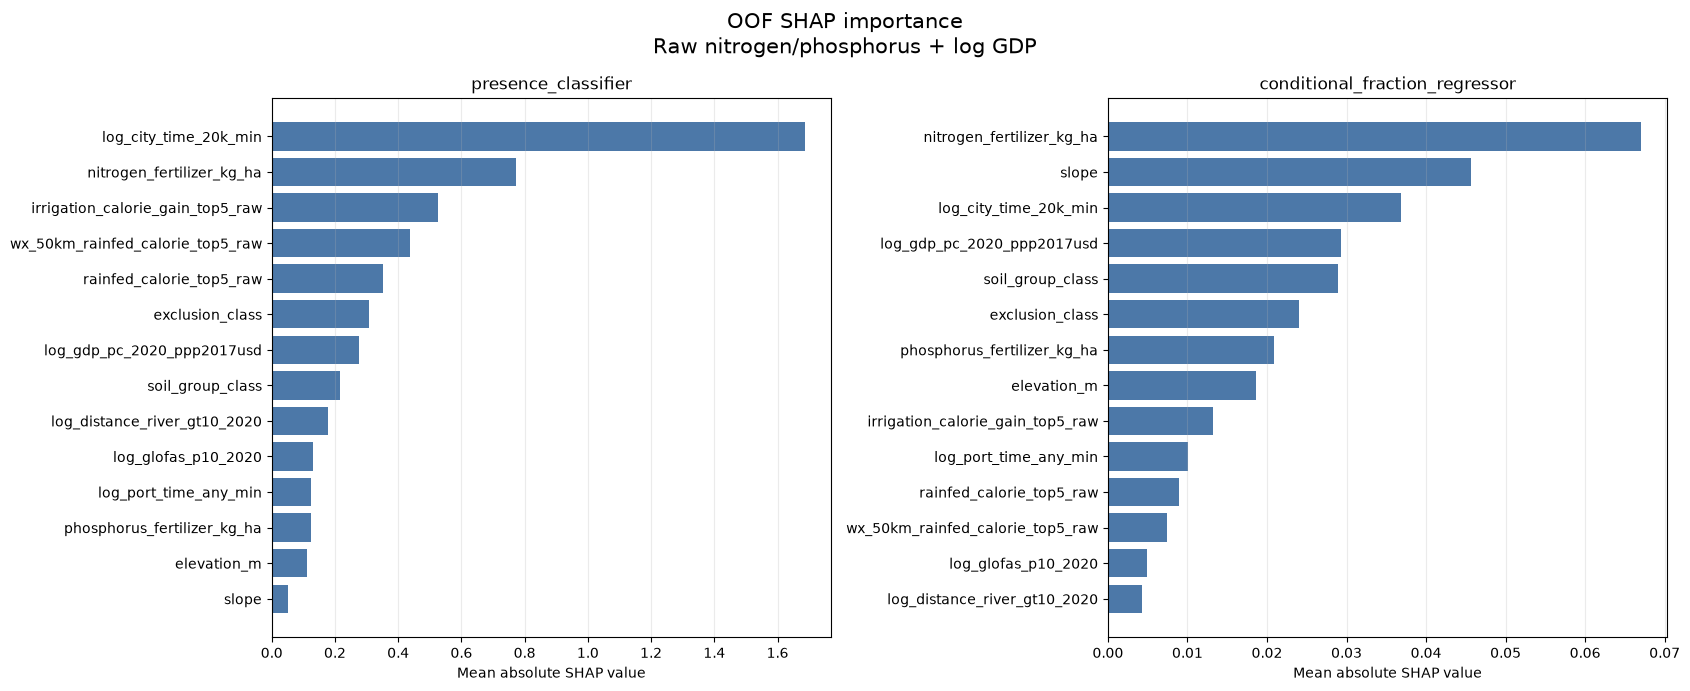

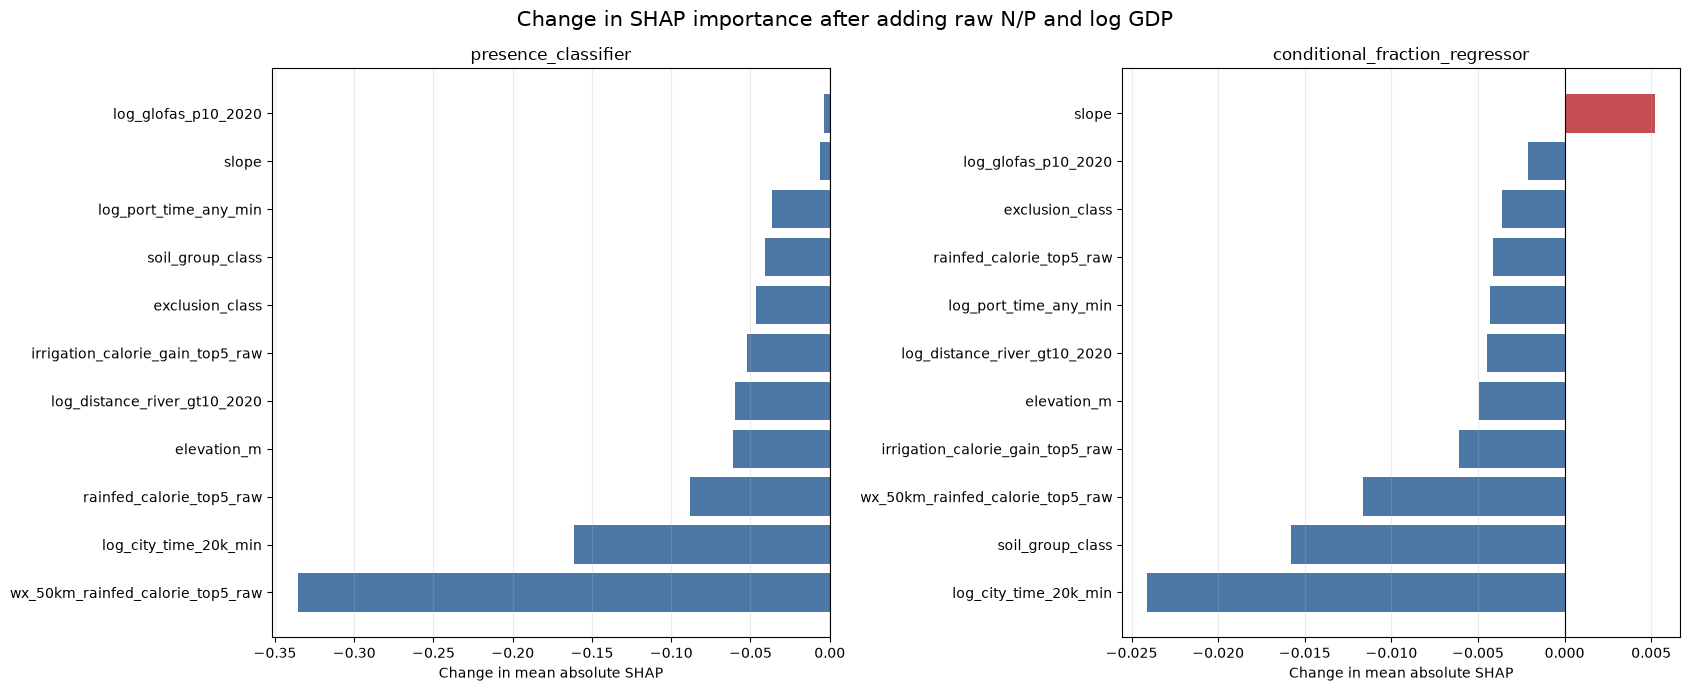

MSE改善量とOOF SHAP比較が完了しました。
出力先: /work/tsuda/GAEZ/CroplandRegression/soil_group_nutrients_gdp_target2020


In [14]:
# ============================================================
# OOF MSE改善量とOOF SHAP比較
#
# 窒素・リン：raw値
# GDP：log1p
# ============================================================

import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap


# ============================================================
# 0. 必要な変数の確認
# ============================================================

required_objects = [
    "work",
    "model_specs",
    "oof_splits",
    "fit_models",
    "prediction_by_model",
    "global_metrics_npgdp",
    "OUTPUT_DIR_NPGDP",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "先にOOF分析セルを実行してください。\n"
        f"不足している変数: {missing_objects}"
    )


BASELINE_MODEL = "baseline"
ADDED_MODEL = "plus_raw_fertilizer_log_gdp"

ADDED_FEATURES = [
    "nitrogen_fertilizer_kg_ha",
    "phosphorus_fertilizer_kg_ha",
    "log_gdp_pc_2020_ppp2017usd",
]


# ============================================================
# 1. MSE・R2の改善量
# ============================================================

metrics_table = global_metrics_npgdp.copy()

required_metric_columns = [
    "model",
    "weighting",
    "r2",
    "rmse",
]

missing_metric_columns = [
    column
    for column in required_metric_columns
    if column not in metrics_table.columns
]

if missing_metric_columns:
    raise RuntimeError(
        "global_metrics_npgdpに必要な列がありません。\n"
        f"不足している列: {missing_metric_columns}"
    )


metrics_table["mse"] = (
    metrics_table["rmse"] ** 2
)

baseline_metrics = (
    metrics_table[
        metrics_table["model"]
        == BASELINE_MODEL
    ]
    .set_index("weighting")
)

added_metrics = (
    metrics_table[
        metrics_table["model"]
        == ADDED_MODEL
    ]
    .set_index("weighting")
)


mse_improvement_rows = []

for weighting in sorted(
    set(baseline_metrics.index)
    & set(added_metrics.index)
):

    baseline_row = baseline_metrics.loc[
        weighting
    ]

    added_row = added_metrics.loc[
        weighting
    ]

    baseline_mse = float(
        baseline_row["mse"]
    )

    added_mse = float(
        added_row["mse"]
    )

    baseline_r2 = float(
        baseline_row["r2"]
    )

    added_r2 = float(
        added_row["r2"]
    )

    mse_reduction = (
        baseline_mse
        - added_mse
    )

    mse_reduction_percent = (
        100.0
        * mse_reduction
        / baseline_mse
        if baseline_mse != 0
        else np.nan
    )

    mse_improvement_rows.append({
        "weighting": weighting,
        "baseline_r2": baseline_r2,
        "added_model_r2": added_r2,
        "r2_change": (
            added_r2
            - baseline_r2
        ),
        "baseline_rmse": float(
            baseline_row["rmse"]
        ),
        "added_model_rmse": float(
            added_row["rmse"]
        ),
        "baseline_mse": baseline_mse,
        "added_model_mse": added_mse,
        "mse_reduction": mse_reduction,
        "mse_reduction_percent": (
            mse_reduction_percent
        ),
    })


mse_improvement = pd.DataFrame(
    mse_improvement_rows
)

print("MSE・R2改善量")

display(
    mse_improvement.round(6)
)


mse_improvement.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_mse_improvement.csv",
    index=False,
    encoding="utf-8-sig",
)


# ============================================================
# 2. MSE改善図
# ============================================================

plot_weightings = (
    mse_improvement[
        "weighting"
    ].tolist()
)

x = np.arange(
    len(plot_weightings)
)

width = 0.35

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
)


# R2
ax = axes[0]

baseline_r2_values = (
    mse_improvement[
        "baseline_r2"
    ].to_numpy()
)

added_r2_values = (
    mse_improvement[
        "added_model_r2"
    ].to_numpy()
)

bars1 = ax.bar(
    x - width / 2,
    baseline_r2_values,
    width,
    label="Baseline",
)

bars2 = ax.bar(
    x + width / 2,
    added_r2_values,
    width,
    label="Raw N/P + log GDP",
)

for bars in [
    bars1,
    bars2,
]:

    for bar in bars:

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_title(
    "OOF R² comparison"
)

ax.set_ylabel(
    "OOF R²"
)

ax.set_xticks(x)

ax.set_xticklabels([
    value.replace(
        "_",
        "\n",
    )
    for value in plot_weightings
])

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25,
)


# MSE削減率
ax = axes[1]

mse_reduction_values = (
    mse_improvement[
        "mse_reduction_percent"
    ].to_numpy()
)

bars = ax.bar(
    x,
    mse_reduction_values,
    width=0.55,
    color="#4C78A8",
)

for bar, value in zip(
    bars,
    mse_reduction_values,
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.axhline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_title(
    "MSE reduction"
)

ax.set_ylabel(
    "MSE reduction (%)"
)

ax.set_xticks(x)

ax.set_xticklabels([
    value.replace(
        "_",
        "\n",
    )
    for value in plot_weightings
])

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.suptitle(
    "Accuracy improvement from raw fertilizer and log GDP",
    fontsize=15,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_mse_improvement.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 3. OOF SHAP用の関数
# ============================================================

def extract_tree_shap(
    explainer,
    values,
):
    """
    LightGBMのTreeExplainer出力を
    (n_observations, n_features)に揃える。
    """

    shap_values = explainer.shap_values(
        values
    )

    if isinstance(
        shap_values,
        list,
    ):
        shap_values = shap_values[-1]

    shap_values = np.asarray(
        shap_values
    )

    if shap_values.ndim == 3:
        shap_values = shap_values[
            :,
            :,
            -1,
        ]

    if shap_values.ndim != 2:
        raise ValueError(
            "予期しないSHAP shapeです: "
            f"{shap_values.shape}"
        )

    return shap_values


def select_positions(
    n_rows,
    max_rows,
    seed,
):
    """
    SHAP計算用の行をサンプリングする。
    """

    if n_rows <= max_rows:
        return np.arange(
            n_rows,
            dtype=int,
        )

    rng = np.random.default_rng(
        seed
    )

    return np.sort(
        rng.choice(
            n_rows,
            size=max_rows,
            replace=False,
        )
    )


def append_shap_rows(
    output_rows,
    model_name,
    stage,
    fold_number,
    features,
    shap_values,
    weights,
):
    """
    SHAPを面積加重集計用の行として保存する。
    """

    shap_values = np.asarray(
        shap_values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    for feature_index, feature in enumerate(
        features
    ):

        feature_shap = shap_values[
            :,
            feature_index,
        ]

        valid = (
            np.isfinite(feature_shap)
            & np.isfinite(weights)
            & (weights > 0)
        )

        if not valid.any():
            continue

        values = feature_shap[
            valid
        ]

        valid_weights = weights[
            valid
        ]

        output_rows.append({
            "model": model_name,
            "stage": stage,
            "fold": fold_number,
            "feature": feature,
            "sum_weight": float(
                valid_weights.sum()
            ),
            "sum_abs_shap_weighted": float(
                np.sum(
                    valid_weights
                    * np.abs(values)
                )
            ),
            "sum_signed_shap_weighted": float(
                np.sum(
                    valid_weights
                    * values
                )
            ),
            "n": int(len(values)),
        })


# ============================================================
# 4. SHAPの重み
# ============================================================

SHAP_MAX_ROWS_PER_FOLD = 5_000

if (
    "analysis_area_weight" in globals()
    and analysis_area_weight is not None
    and len(analysis_area_weight)
    == len(work)
):

    shap_area_weight = np.asarray(
        analysis_area_weight,
        dtype=float,
    )

else:

    shap_area_weight = np.ones(
        len(work),
        dtype=float,
    )


# ============================================================
# 5. 空間OOF SHAPを計算
# ============================================================

shap_fold_rows = []

print(
    "OOF SHAPの再計算を開始します。"
)

for model_name, features in (
    model_specs.items()
):

    print("=" * 80)
    print(
        f"SHAP model: {model_name}"
    )
    print("=" * 80)

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(
        oof_splits,
        start=1,
    ):

        print(
            f"fold {fold_number}/{N_SPLITS}",
            flush=True,
        )

        train_df = work.iloc[
            train_idx
        ]

        test_df = work.iloc[
            test_idx
        ]

        classifier, regressor = fit_models(
            train_df,
            features,
            fold_number,
        )


        # ----------------------------------------------------
        # 5-1. presence classifierのSHAP
        # ----------------------------------------------------

        selected_presence = select_positions(
            n_rows=len(test_df),
            max_rows=SHAP_MAX_ROWS_PER_FOLD,
            seed=(
                RANDOM_SEED
                + 10_000
                + fold_number
            ),
        )

        presence_frame = test_df.iloc[
            selected_presence
        ]

        presence_global_idx = test_idx[
            selected_presence
        ]

        presence_shap = extract_tree_shap(
            shap.TreeExplainer(
                classifier
            ),
            presence_frame[
                features
            ],
        )

        presence_weights = (
            shap_area_weight[
                presence_global_idx
            ]
        )

        append_shap_rows(
            shap_fold_rows,
            model_name,
            "presence_classifier",
            fold_number,
            features,
            presence_shap,
            presence_weights,
        )


        # ----------------------------------------------------
        # 5-2. 条件付き耕作地割合regressorのSHAP
        # ----------------------------------------------------

        positive_positions = np.flatnonzero(
            test_df[
                "presence"
            ].to_numpy(
                dtype=np.uint8
            )
            == 1
        )

        if len(positive_positions) > 0:

            selected_positive_local = (
                select_positions(
                    n_rows=len(
                        positive_positions
                    ),
                    max_rows=SHAP_MAX_ROWS_PER_FOLD,
                    seed=(
                        RANDOM_SEED
                        + 20_000
                        + fold_number
                    ),
                )
            )

            selected_positive = (
                positive_positions[
                    selected_positive_local
                ]
            )

            fraction_frame = test_df.iloc[
                selected_positive
            ]

            fraction_global_idx = test_idx[
                selected_positive
            ]

            fraction_shap = extract_tree_shap(
                shap.TreeExplainer(
                    regressor
                ),
                fraction_frame[
                    features
                ],
            )

            fraction_weights = (
                shap_area_weight[
                    fraction_global_idx
                ]
            )

            append_shap_rows(
                shap_fold_rows,
                model_name,
                "conditional_fraction_regressor",
                fold_number,
                features,
                fraction_shap,
                fraction_weights,
            )


        del classifier
        del regressor

        gc.collect()


shap_fold_summary = pd.DataFrame(
    shap_fold_rows
)


# ============================================================
# 6. SHAP全fold集計
# ============================================================

shap_summary = (
    shap_fold_summary
    .groupby(
        [
            "model",
            "stage",
            "feature",
        ],
        as_index=False,
    )
    .agg(
        sum_weight=(
            "sum_weight",
            "sum",
        ),
        sum_abs_shap_weighted=(
            "sum_abs_shap_weighted",
            "sum",
        ),
        sum_signed_shap_weighted=(
            "sum_signed_shap_weighted",
            "sum",
        ),
        n=(
            "n",
            "sum",
        ),
    )
)

shap_summary[
    "mean_abs_shap"
] = (
    shap_summary[
        "sum_abs_shap_weighted"
    ]
    / shap_summary[
        "sum_weight"
    ]
)

shap_summary[
    "mean_signed_shap"
] = (
    shap_summary[
        "sum_signed_shap_weighted"
    ]
    / shap_summary[
        "sum_weight"
    ]
)

shap_summary[
    "relative_importance_share"
] = (
    shap_summary
    .groupby(
        [
            "model",
            "stage",
        ]
    )[
        "mean_abs_shap"
    ]
    .transform(
        lambda values:
        values / values.sum()
    )
)


shap_summary = shap_summary.sort_values(
    [
        "stage",
        "model",
        "mean_abs_shap",
    ],
    ascending=[
        True,
        True,
        False,
    ],
)


# ============================================================
# 7. 追加変数のSHAP
# ============================================================

added_feature_shap = shap_summary[
    (
        shap_summary["model"]
        == ADDED_MODEL
    )
    & (
        shap_summary["feature"].isin(
            ADDED_FEATURES
        )
    )
].copy()

print(
    "追加変数のSHAP重要度"
)

display(
    added_feature_shap[
        [
            "model",
            "stage",
            "feature",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ].round(6)
)


# ============================================================
# 8. baselineと追加モデルの共通変数のSHAP比較
# ============================================================

baseline_shap = (
    shap_summary[
        shap_summary["model"]
        == BASELINE_MODEL
    ][
        [
            "stage",
            "feature",
            "mean_abs_shap",
            "mean_signed_shap",
        ]
    ]
    .rename(columns={
        "mean_abs_shap": (
            "baseline_mean_abs_shap"
        ),
        "mean_signed_shap": (
            "baseline_mean_signed_shap"
        ),
    })
)

added_model_shap = (
    shap_summary[
        shap_summary["model"]
        == ADDED_MODEL
    ][
        [
            "stage",
            "feature",
            "mean_abs_shap",
            "mean_signed_shap",
        ]
    ]
    .rename(columns={
        "mean_abs_shap": (
            "added_model_mean_abs_shap"
        ),
        "mean_signed_shap": (
            "added_model_mean_signed_shap"
        ),
    })
)

shap_compare = pd.merge(
    baseline_shap,
    added_model_shap,
    on=[
        "stage",
        "feature",
    ],
    how="outer",
)

shap_compare[
    "change_in_mean_abs_shap"
] = (
    shap_compare[
        "added_model_mean_abs_shap"
    ]
    - shap_compare[
        "baseline_mean_abs_shap"
    ]
)

shap_compare[
    "change_in_mean_abs_shap_percent"
] = (
    100.0
    * shap_compare[
        "change_in_mean_abs_shap"
    ]
    / shap_compare[
        "baseline_mean_abs_shap"
    ]
)


print(
    "共通変数のSHAP変化"
)

display(
    shap_compare.sort_values(
        [
            "stage",
            "change_in_mean_abs_shap",
        ],
        ascending=[
            True,
            False,
        ],
    ).round(6)
)


# ============================================================
# 9. SHAP結果の保存
# ============================================================

shap_fold_summary.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_oof_shap_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

shap_summary.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_oof_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

added_feature_shap.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_added_feature_shap.csv",
    index=False,
    encoding="utf-8-sig",
)

shap_compare.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_shap_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)


# ============================================================
# 10. 追加モデルのSHAP重要度図
# ============================================================

hybrid_shap = shap_summary[
    shap_summary["model"]
    == ADDED_MODEL
].copy()

stages = [
    "presence_classifier",
    "conditional_fraction_regressor",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7),
)

for ax, stage in zip(
    axes,
    stages,
):

    plot_data = hybrid_shap[
        hybrid_shap["stage"]
        == stage
    ].sort_values(
        "mean_abs_shap",
        ascending=True,
    )

    ax.barh(
        plot_data["feature"],
        plot_data["mean_abs_shap"],
        color="#4C78A8",
    )

    ax.set_title(
        stage
    )

    ax.set_xlabel(
        "Mean absolute SHAP value"
    )

    ax.grid(
        axis="x",
        alpha=0.25,
    )


fig.suptitle(
    "OOF SHAP importance\n"
    "Raw nitrogen/phosphorus + log GDP",
    fontsize=15,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_oof_shap_importance.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 11. 共通変数のSHAP変化図
# ============================================================

common_shap_change = shap_compare[
    shap_compare["baseline_mean_abs_shap"]
    .notna()
    & shap_compare[
        "added_model_mean_abs_shap"
    ].notna()
].copy()


fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 7),
)

for ax, stage in zip(
    axes,
    stages,
):

    plot_data = common_shap_change[
        common_shap_change["stage"]
        == stage
    ].sort_values(
        "change_in_mean_abs_shap",
        ascending=True,
    )

    colors = np.where(
        plot_data[
            "change_in_mean_abs_shap"
        ] >= 0,
        "#C44E52",
        "#4C78A8",
    )

    ax.barh(
        plot_data["feature"],
        plot_data[
            "change_in_mean_abs_shap"
        ],
        color=colors,
    )

    ax.axvline(
        0,
        color="black",
        linewidth=0.8,
    )

    ax.set_title(
        stage
    )

    ax.set_xlabel(
        "Change in mean absolute SHAP"
    )

    ax.grid(
        axis="x",
        alpha=0.25,
    )


fig.suptitle(
    "Change in SHAP importance after adding raw N/P and log GDP",
    fontsize=15,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_shap_change.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


print(
    "MSE改善量とOOF SHAP比較が完了しました。"
)

print(
    "出力先:",
    OUTPUT_DIR_NPGDP,
)

## 統合すると？？

Integrated SHAP: baseline
fold 1/5
fold 2/5
fold 3/5
fold 4/5
fold 5/5
Integrated SHAP: plus_raw_fertilizer_log_gdp
fold 1/5
fold 2/5
fold 3/5
fold 4/5
fold 5/5
統合予測に対するSHAP比較


,feature,baseline_mean_abs_integrated_shap,baseline_mean_signed_integrated_shap,baseline_relative_share,added_model_mean_abs_integrated_shap,added_model_mean_signed_integrated_shap,added_model_relative_share,change_in_mean_abs_integrated_shap,change_in_mean_abs_integrated_shap_percent
3,log_city_time_20k_min,0.060305,-0.014765,0.280769,0.045052,-0.011151,0.196702,-0.015253,-25.292998
8,nitrogen_fertilizer_kg_ha,NaN,NaN,NaN,0.042619,-0.010991,0.186079,NaN,NaN
1,exclusion_class,0.021188,-0.002367,0.098648,0.017791,-0.002187,0.077679,-0.003397,-16.031639
11,slope,0.014234,-0.001170,0.066273,0.016846,-0.001333,0.073550,0.002611,18.345605
5,log_gdp_pc_2020_ppp2017usd,NaN,NaN,NaN,0.014932,0.000987,0.065193,NaN,NaN
12,soil_group_class,0.022499,-0.006060,0.104751,0.014862,-0.004574,0.064889,-0.007637,-33.943102
13,wx_50km_rainfed_calorie_top5_raw,0.029251,-0.006850,0.136189,0.014692,-0.003425,0.064147,-0.014559,-49.773323
10,rainfed_calorie_top5_raw,0.018919,-0.004209,0.088084,0.013628,-0.002564,0.059502,-0.005291,-27.967167
9,phosphorus_fertilizer_kg_ha,NaN,NaN,NaN,0.013583,-0.002432,0.059306,NaN,NaN
2,irrigation_calorie_gain_top5_raw,0.015747,-0.000819,0.073315,0.012460,-0.000501,0.054402,-0.003287,-20.873376


追加変数の統合SHAP


,feature,mean_abs_shap,mean_signed_shap,relative_importance_share
16,log_gdp_pc_2020_ppp2017usd,0.014932,0.000987,0.065193
19,nitrogen_fertilizer_kg_ha,0.042619,-0.010991,0.186079
20,phosphorus_fertilizer_kg_ha,0.013583,-0.002432,0.059306


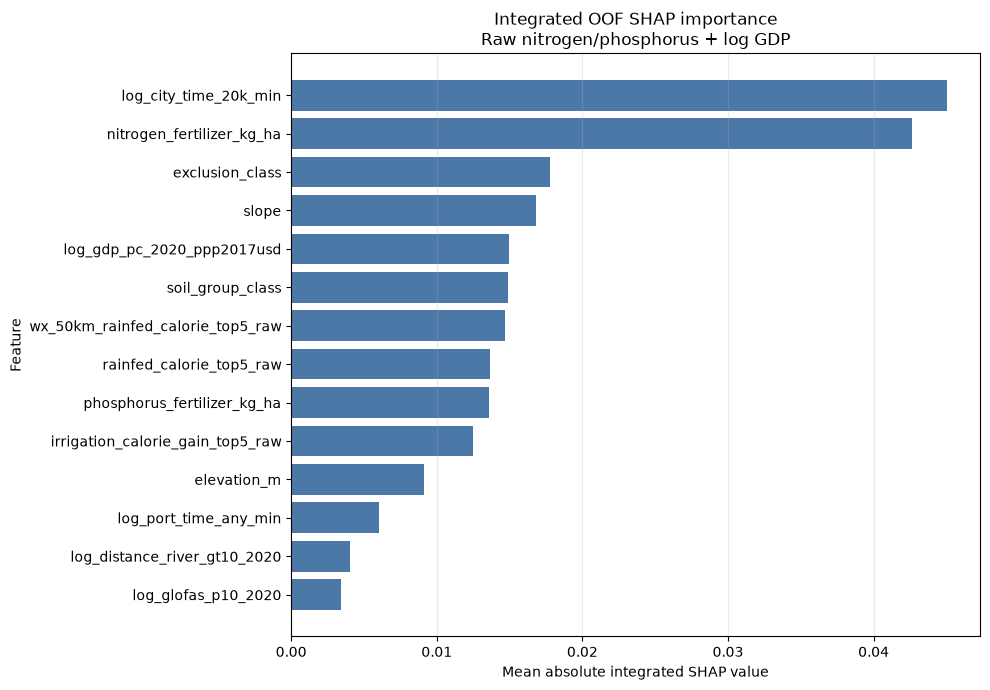

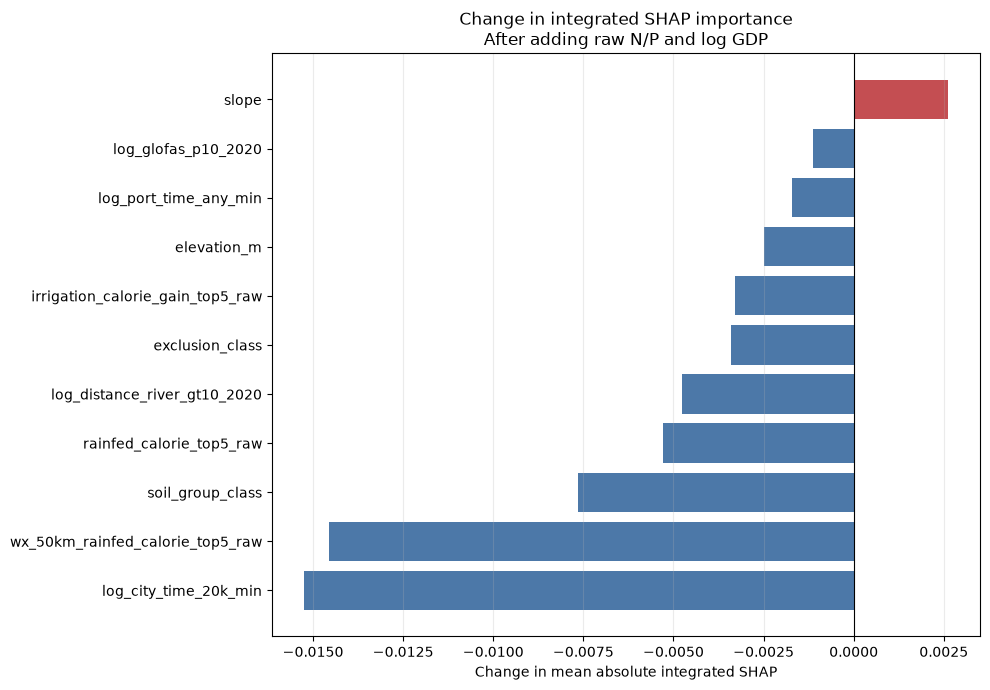

統合予測の再現誤差


,model,fold,mean_absolute_difference,max_absolute_difference
0,baseline,1,2.900000e-09,2.920000e-08
1,baseline,2,2.000000e-09,2.950000e-08
2,baseline,3,3.300000e-09,2.980000e-08
3,baseline,4,2.900000e-09,2.900000e-08
4,baseline,5,2.200000e-09,2.970000e-08
5,plus_raw_fertilizer_log_gdp,1,2.600000e-09,2.820000e-08
6,plus_raw_fertilizer_log_gdp,2,2.100000e-09,2.870000e-08
7,plus_raw_fertilizer_log_gdp,3,3.600000e-09,2.950000e-08
8,plus_raw_fertilizer_log_gdp,4,2.900000e-09,2.900000e-08
9,plus_raw_fertilizer_log_gdp,5,2.500000e-09,2.790000e-08


統合OOF SHAPの計算が完了しました。
出力先: /work/tsuda/GAEZ/CroplandRegression/soil_group_nutrients_gdp_target2020


In [15]:
# ============================================================
# 統合予測に対するOOF SHAP
#
# 最終予測 =
# presence probability
# × conditional cropland fraction
#
# 窒素・リン：raw値
# GDP：log1p
# ============================================================

import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap


# ============================================================
# 0. 必要な変数の確認
# ============================================================

required_objects = [
    "work",
    "model_specs",
    "oof_splits",
    "fit_models",
    "adjust_probability_prior_shift",
    "target_prior",
    "prediction_by_model",
    "OUTPUT_DIR_NPGDP",
    "RANDOM_SEED",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "先にOOF分析セルを実行してください。\n"
        f"不足している変数: {missing_objects}"
    )


BASELINE_MODEL = "baseline"

ADDED_MODEL = (
    "plus_raw_fertilizer_log_gdp"
)

SHAP_ROWS_PER_FOLD = 300
SHAP_BACKGROUND_ROWS = 100
SHAP_PERMUTATIONS = 2


# ============================================================
# 1. SHAP用の面積重み
# ============================================================

if (
    "analysis_area_weight" in globals()
    and analysis_area_weight is not None
    and len(analysis_area_weight) == len(work)
):

    integrated_shap_weights = np.asarray(
        analysis_area_weight,
        dtype=float,
    )

else:

    integrated_shap_weights = np.ones(
        len(work),
        dtype=float,
    )


# ============================================================
# 2. categorical変数を数値化する関数
# ============================================================

def make_category_metadata(
    frame,
    features,
):
    """
    categorical変数のカテゴリ順を保存する。
    """

    metadata = {}

    for feature in features:

        if (
            feature in CATEGORICAL_CANDIDATES
            and feature in frame.columns
        ):

            column = frame[feature]

            if isinstance(
                column.dtype,
                pd.CategoricalDtype,
            ):

                categories = (
                    column.cat.categories
                )

            else:

                categories = pd.Index(
                    sorted(
                        column.dropna()
                        .unique()
                    )
                )

            metadata[feature] = categories

    return metadata


def frame_to_numeric_matrix(
    frame,
    features,
    category_metadata,
):
    """
    LightGBM用DataFrameを
    SHAP計算用の数値行列へ変換する。
    """

    matrix = np.zeros(
        (
            len(frame),
            len(features),
        ),
        dtype=float,
    )

    for feature_index, feature in enumerate(
        features
    ):

        if feature in category_metadata:

            categories = (
                category_metadata[feature]
            )

            categorical = pd.Categorical(
                frame[feature],
                categories=categories,
            )

            matrix[
                :,
                feature_index,
            ] = categorical.codes.astype(
                float
            )

        else:

            matrix[
                :,
                feature_index,
            ] = pd.to_numeric(
                frame[feature],
                errors="coerce",
            ).to_numpy(
                dtype=float
            )

    return matrix


def numeric_matrix_to_frame(
    matrix,
    features,
    category_metadata,
):
    """
    SHAP計算用の数値行列を
    LightGBM入力用DataFrameへ戻す。
    """

    matrix = np.asarray(
        matrix,
        dtype=float,
    )

    if matrix.ndim == 1:
        matrix = matrix.reshape(
            1,
            -1,
        )

    frame = pd.DataFrame(
        index=np.arange(
            len(matrix)
        )
    )

    for feature_index, feature in enumerate(
        features
    ):

        values = matrix[
            :,
            feature_index,
        ]

        if feature in category_metadata:

            categories = (
                category_metadata[feature]
            )

            codes = np.where(
                np.isfinite(values),
                np.rint(values),
                0,
            ).astype(int)

            codes = np.clip(
                codes,
                0,
                len(categories) - 1,
            )

            frame[feature] = (
                pd.Categorical.from_codes(
                    codes,
                    categories=categories,
                )
            )

        else:

            frame[feature] = values

    return frame


# ============================================================
# 3. 統合予測関数
# ============================================================

def build_integrated_predict_function(
    classifier,
    regressor,
    train_prior,
    target_prior,
    features,
    category_metadata,
):
    """
    presence classifierと
    conditional fraction regressorを統合した
    最終耕作地割合の予測関数を作る。
    """

    def integrated_predict(values):

        if isinstance(
            values,
            pd.DataFrame,
        ):

            values_matrix = (
                frame_to_numeric_matrix(
                    values,
                    features,
                    category_metadata,
                )
            )

        else:

            values_matrix = np.asarray(
                values,
                dtype=float,
            )

            if values_matrix.ndim == 1:
                values_matrix = (
                    values_matrix.reshape(
                        1,
                        -1,
                    )
                )

        values_frame = (
            numeric_matrix_to_frame(
                values_matrix,
                features,
                category_metadata,
            )
        )

        raw_probability = (
            classifier.predict_proba(
                values_frame[features]
            )[:, 1]
        )

        calibrated_probability = (
            adjust_probability_prior_shift(
                raw_probability,
                train_prior,
                target_prior,
            )
        )

        conditional_fraction = np.clip(
            regressor.predict(
                values_frame[features]
            ),
            0.0,
            1.0,
        )

        integrated_prediction = (
            calibrated_probability
            * conditional_fraction
        )

        return np.asarray(
            integrated_prediction,
            dtype=float,
        )

    return integrated_predict


# ============================================================
# 4. 統合OOF SHAPの計算
# ============================================================

integrated_shap_rows = []
integrated_shap_local_rows = []
prediction_check_rows = []


for model_name, features in (
    model_specs.items()
):

    print("=" * 80)
    print(
        "Integrated SHAP:",
        model_name,
    )
    print("=" * 80)

    for fold_number, (
        train_idx,
        test_idx,
    ) in enumerate(
        oof_splits,
        start=1,
    ):

        print(
            f"fold {fold_number}/{N_SPLITS}",
            flush=True,
        )

        train_df = work.iloc[
            train_idx
        ]

        test_df = work.iloc[
            test_idx
        ]

        classifier, regressor = fit_models(
            train_df,
            features,
            fold_number,
        )

        category_metadata = (
            make_category_metadata(
                work,
                features,
            )
        )

        integrated_predict = (
            build_integrated_predict_function(
                classifier,
                regressor,
                float(
                    train_df[
                        "presence"
                    ].mean()
                ),
                target_prior,
                features,
                category_metadata,
            )
        )


        # ----------------------------------------------------
        # 背景データ
        # ----------------------------------------------------

        background_positions = np.sort(
            np.random.default_rng(
                RANDOM_SEED
                + 30_000
                + fold_number
            ).choice(
                len(train_df),
                size=min(
                    SHAP_BACKGROUND_ROWS,
                    len(train_df),
                ),
                replace=False,
            )
        )

        background_frame = train_df.iloc[
            background_positions
        ]

        background_matrix = (
            frame_to_numeric_matrix(
                background_frame,
                features,
                category_metadata,
            )
        )


        # ----------------------------------------------------
        # 説明対象データ
        # ----------------------------------------------------

        explain_positions = (
            select_positions(
                len(test_df),
                SHAP_ROWS_PER_FOLD,
                RANDOM_SEED
                + 40_000
                + fold_number,
            )
        )

        explain_frame = test_df.iloc[
            explain_positions
        ]

        explain_global_idx = test_idx[
            explain_positions
        ]

        explain_matrix = (
            frame_to_numeric_matrix(
                explain_frame,
                features,
                category_metadata,
            )
        )


        # ----------------------------------------------------
        # 統合予測関数の確認
        # ----------------------------------------------------

        integrated_prediction_check = (
            integrated_predict(
                explain_matrix
            )
        )

        saved_prediction = (
            prediction_by_model[
                model_name
            ][
                explain_global_idx
            ]
        )

        prediction_check_rows.append({
            "model": model_name,
            "fold": fold_number,
            "mean_absolute_difference": float(
                np.mean(
                    np.abs(
                        integrated_prediction_check
                        - saved_prediction
                    )
                )
            ),
            "max_absolute_difference": float(
                np.max(
                    np.abs(
                        integrated_prediction_check
                        - saved_prediction
                    )
                )
            ),
        })


        # ----------------------------------------------------
        # Permutation SHAP
        # ----------------------------------------------------

        masker = shap.maskers.Independent(
            background_matrix,
            max_samples=len(
                background_matrix
            ),
        )

        explainer = shap.Explainer(
            integrated_predict,
            masker,
            algorithm="permutation",
        )

        max_evals = (
            (
                2 * len(features)
                + 1
            )
            * SHAP_PERMUTATIONS
        )

        shap_result = explainer(
            explain_matrix,
            max_evals=max_evals,
            silent=True,
        )

        integrated_shap_values = np.asarray(
            shap_result.values,
            dtype=float,
        )

        if integrated_shap_values.ndim == 3:
            integrated_shap_values = (
                integrated_shap_values[:, :, 0]
            )


        # ----------------------------------------------------
        # SHAP集計
        # ----------------------------------------------------

        shap_weights = (
            integrated_shap_weights[
                explain_global_idx
            ]
        )

        for feature_index, feature in enumerate(
            features
        ):

            values = integrated_shap_values[
                :,
                feature_index,
            ]

            valid = (
                np.isfinite(values)
                & np.isfinite(shap_weights)
                & (shap_weights > 0)
            )

            if not valid.any():
                continue

            valid_values = values[
                valid
            ]

            valid_weights = shap_weights[
                valid
            ]

            integrated_shap_rows.append({
                "model": model_name,
                "stage": "integrated_prediction",
                "fold": fold_number,
                "feature": feature,
                "sum_weight": float(
                    valid_weights.sum()
                ),
                "sum_abs_shap_weighted": float(
                    np.sum(
                        valid_weights
                        * np.abs(
                            valid_values
                        )
                    )
                ),
                "sum_signed_shap_weighted": float(
                    np.sum(
                        valid_weights
                        * valid_values
                    )
                ),
                "n": int(
                    len(valid_values)
                ),
            })


        # ----------------------------------------------------
        # ローカルSHAP保存
        # ----------------------------------------------------

        for local_index, global_index in enumerate(
            explain_global_idx
        ):

            local_row = {
                "model": model_name,
                "fold": fold_number,
                "sample_index": int(
                    global_index
                ),
                "row": int(
                    work.iloc[
                        global_index
                    ]["row"]
                ),
                "col": int(
                    work.iloc[
                        global_index
                    ]["col"]
                ),
                "lat": float(
                    work.iloc[
                        global_index
                    ]["lat"]
                ),
                "lon": float(
                    work.iloc[
                        global_index
                    ]["lon"]
                ),
                "observed": float(
                    work.iloc[
                        global_index
                    ]["cropland_fraction"]
                ),
                "integrated_prediction": float(
                    integrated_prediction_check[
                        local_index
                    ]
                ),
            }

            for feature_index, feature in enumerate(
                features
            ):

                local_row[
                    f"shap__{feature}"
                ] = float(
                    integrated_shap_values[
                        local_index,
                        feature_index,
                    ]
                )

            integrated_shap_local_rows.append(
                local_row
            )


        del classifier
        del regressor
        del explainer

        gc.collect()


# ============================================================
# 5. 統合SHAP全fold集計
# ============================================================

integrated_shap_fold_summary = pd.DataFrame(
    integrated_shap_rows
)

integrated_shap_summary = (
    integrated_shap_fold_summary
    .groupby(
        [
            "model",
            "stage",
            "feature",
        ],
        as_index=False,
    )
    .agg(
        sum_weight=(
            "sum_weight",
            "sum",
        ),
        sum_abs_shap_weighted=(
            "sum_abs_shap_weighted",
            "sum",
        ),
        sum_signed_shap_weighted=(
            "sum_signed_shap_weighted",
            "sum",
        ),
        n=(
            "n",
            "sum",
        ),
    )
)

integrated_shap_summary[
    "mean_abs_shap"
] = (
    integrated_shap_summary[
        "sum_abs_shap_weighted"
    ]
    / integrated_shap_summary[
        "sum_weight"
    ]
)

integrated_shap_summary[
    "mean_signed_shap"
] = (
    integrated_shap_summary[
        "sum_signed_shap_weighted"
    ]
    / integrated_shap_summary[
        "sum_weight"
    ]
)

integrated_shap_summary[
    "relative_importance_share"
] = (
    integrated_shap_summary
    .groupby(
        [
            "model",
            "stage",
        ]
    )[
        "mean_abs_shap"
    ]
    .transform(
        lambda values:
        values / values.sum()
    )
)


# ============================================================
# 6. 統合SHAPの比較
# ============================================================

baseline_integrated_shap = (
    integrated_shap_summary[
        integrated_shap_summary["model"]
        == BASELINE_MODEL
    ][
        [
            "feature",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ]
    .rename(columns={
        "mean_abs_shap": (
            "baseline_mean_abs_integrated_shap"
        ),
        "mean_signed_shap": (
            "baseline_mean_signed_integrated_shap"
        ),
        "relative_importance_share": (
            "baseline_relative_share"
        ),
    })
)

added_integrated_shap = (
    integrated_shap_summary[
        integrated_shap_summary["model"]
        == ADDED_MODEL
    ][
        [
            "feature",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ]
    .rename(columns={
        "mean_abs_shap": (
            "added_model_mean_abs_integrated_shap"
        ),
        "mean_signed_shap": (
            "added_model_mean_signed_integrated_shap"
        ),
        "relative_importance_share": (
            "added_model_relative_share"
        ),
    })
)

integrated_shap_compare = pd.merge(
    baseline_integrated_shap,
    added_integrated_shap,
    on="feature",
    how="outer",
)

integrated_shap_compare[
    "change_in_mean_abs_integrated_shap"
] = (
    integrated_shap_compare[
        "added_model_mean_abs_integrated_shap"
    ]
    - integrated_shap_compare[
        "baseline_mean_abs_integrated_shap"
    ]
)

integrated_shap_compare[
    "change_in_mean_abs_integrated_shap_percent"
] = (
    100.0
    * integrated_shap_compare[
        "change_in_mean_abs_integrated_shap"
    ]
    / integrated_shap_compare[
        "baseline_mean_abs_integrated_shap"
    ]
)


print(
    "統合予測に対するSHAP比較"
)

display(
    integrated_shap_compare.sort_values(
        "added_model_mean_abs_integrated_shap",
        ascending=False,
    ).round(6)
)


print(
    "追加変数の統合SHAP"
)

display(
    integrated_shap_summary[
        (
            integrated_shap_summary["model"]
            == ADDED_MODEL
        )
        & (
            integrated_shap_summary["feature"]
            .isin(
                [
                    "nitrogen_fertilizer_kg_ha",
                    "phosphorus_fertilizer_kg_ha",
                    "log_gdp_pc_2020_ppp2017usd",
                ]
            )
        )
    ][
        [
            "feature",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ].round(6)
)


# ============================================================
# 7. 結果の保存
# ============================================================

integrated_shap_fold_summary.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_integrated_shap_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

integrated_shap_summary.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_integrated_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

integrated_shap_compare.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_integrated_shap_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

integrated_shap_local = pd.DataFrame(
    integrated_shap_local_rows
)

integrated_shap_local.to_csv(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_integrated_local_shap.csv.gz",
    index=False,
    compression="gzip",
)

pd.DataFrame(
    prediction_check_rows
).to_csv(
    OUTPUT_DIR_NPGDP
    / "integrated_shap_prediction_check.csv",
    index=False,
    encoding="utf-8-sig",
)


# ============================================================
# 8. 統合SHAP重要度図
# ============================================================

plot_data = (
    integrated_shap_summary[
        integrated_shap_summary["model"]
        == ADDED_MODEL
    ]
    .sort_values(
        "mean_abs_shap",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    plot_data["feature"],
    plot_data["mean_abs_shap"],
    color="#4C78A8",
)

ax.set_xlabel(
    "Mean absolute integrated SHAP value"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "Integrated OOF SHAP importance\n"
    "Raw nitrogen/phosphorus + log GDP"
)

ax.grid(
    axis="x",
    alpha=0.25,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_integrated_shap_importance.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 9. 共通変数の統合SHAP変化
# ============================================================

common_integrated_change = (
    integrated_shap_compare[
        integrated_shap_compare[
            "baseline_mean_abs_integrated_shap"
        ].notna()
        & integrated_shap_compare[
            "added_model_mean_abs_integrated_shap"
        ].notna()
    ]
    .sort_values(
        "change_in_mean_abs_integrated_shap",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

colors = np.where(
    common_integrated_change[
        "change_in_mean_abs_integrated_shap"
    ] >= 0,
    "#C44E52",
    "#4C78A8",
)

ax.barh(
    common_integrated_change[
        "feature"
    ],
    common_integrated_change[
        "change_in_mean_abs_integrated_shap"
    ],
    color=colors,
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_xlabel(
    "Change in mean absolute integrated SHAP"
)

ax.set_title(
    "Change in integrated SHAP importance\n"
    "After adding raw N/P and log GDP"
)

ax.grid(
    axis="x",
    alpha=0.25,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR_NPGDP
    / "raw_fertilizer_log_gdp_integrated_shap_change.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 10. 検算結果
# ============================================================

prediction_check_table = pd.DataFrame(
    prediction_check_rows
)

print(
    "統合予測の再現誤差"
)

display(
    prediction_check_table.round(10)
)

print(
    "統合OOF SHAPの計算が完了しました。"
)

print(
    "出力先:",
    OUTPUT_DIR_NPGDP,
)